<div style="width: 100%; clear: both;">
<div style="float: left; width: 50%;">
<img src="https://www.uoc.edu/content/dam/news/images/noticies/2016/202-nova-marca-uoc.jpg" align="left" width="45%">
</div>
<div style="float: right; width: 50%;">
<p style="margin: 0; padding-top: 22px; text-align:right;">M2.891 · Aprendizaje automático · PEC4</p>
<p style="margin: 0; text-align:right;">2025-2· Máster universitario en Ciencia de datos (Data science)</p>
<p style="margin: 0; text-align:right; padding-button: 100px;">Estudios de Informática, Multimedia y Telecomunicación</p>
</div>
</div>
<div style="width:100%;">&nbsp;</div>

# **PEC 4: Combinación de Modelos**

## Objetivo
Esta cuarta Práctica de Evaluación Continua (PEC 4) tiene como objetivo principal consolidar los conocimientos adquiridos en las PECs anteriores (introducción al aprendizaje automático, análisis exploratorio de datos, métodos supervisados y no supervisados) e introducir y profundizar en técnicas avanzadas de Ensemble Learning (Aprendizaje por Conjuntos).

Al finalizar esta PEC, deberías ser capaz de:

* Implementar y comparar diversas técnicas de ensemble learning (p. ej., Bagging/Random Forest, Boosting -AdaBoost, Gradient Boosting-, Stacking y cascading) sobre un conjunto de datos específico.
* Analizar y explicar cómo los hiperparámetros clave de los métodos ensemble influyen en su comportamiento y rendimiento.
* Evaluar y comparar la importancia de las características (feature importance) obtenida a través de diferentes modelos ensemble.
* Justificar cuándo y por qué un método ensemble podría ser preferible a otro, o a un modelo individual (conectando con conceptos como el trade-off sesgo-varianza).
* Aplicar correctamente metodologías de validación (como validación cruzada) para la evaluación y comparación robusta de los modelos ensemble.

## Conjunto de datos
La empresa **CloudSync Platforms** opera un ecosistema de software B2B en la nube bajo un modelo de suscripción mensual (SaaS). En este sector, la retención de usuarios es crítica para la rentabilidad a largo plazo. Recientemente, el equipo directivo ha detectado fluctuaciones inusuales en las tasas de abandono y necesita anticiparse al comportamiento de su cartera de clientes para el próximo ciclo de facturación. Esto les permitirá dirigir estratégicamente sus campañas de retención y optimizar la asignación de recursos en sus clústeres de servidores.

El dataset (`cloudsync_churn_data.csv`) contiene 3000 perfiles consolidados de clientes activos durante el último trimestre. El objetivo del equipo de Data Science es predecir el estado de la suscripción del usuario para el mes siguiente, el cual se clasifica en tres posibles escenarios: el cliente renueva su plan (0), el cliente pausa temporalmente su cuenta (1), o el cliente cancela el servicio definitivamente (2). 

La información proporcionada es el resultado de la unión de múltiples fuentes de datos de la compañía: registros técnicos de telemetría del backend, métricas de interacción dentro de la aplicación y datos tradicionales de servicio al cliente (CRM). El equipo de ingeniería de datos advierte que el ecosistema de la plataforma es altamente complejo: existen interacciones ocultas entre las variables de infraestructura y el comportamiento del usuario, y sospechan que los indicadores tradicionales de "satisfacción del cliente" podrían estar enmascarando los verdaderos detonantes técnicos del abandono.  

El equipo directivo ha sido muy claro respecto a las prioridades de esta iniciativa: el peor escenario posible para la compañía es perder a un cliente de forma imprevista (cancelación definitiva). Desde el punto de vista operativo, prefieren que el equipo de soporte dedique recursos preventivos a un usuario que quizá solo iba a pausar su cuenta, antes que dejar escapar a un cliente que estaba a punto de abandonarnos por completo.

Las variables del dataset son las siguientes:

| Variable Objetivo | Estado  | Descripción |
| :--- | :--- | :--- |
| `subscription_status` | `0` (Renovar) | El usuario elige continuar con su suscripción activa y se le facturará normalmente el próximo ciclo. |
| `subscription_status` | `1` (Pausar) | El usuario suspende temporalmente su cuenta, deteniendo la facturación pero conservando su perfil y datos para un posible regreso en el futuro. |
| `subscription_status` | `2` (Cancelar) | El usuario termina permanentemente su suscripción y abandona la plataforma (este es el evento final de abandono o *churn* que la empresa desea evitar). |

<br>

| Variable Predictora | Descripción |
| :--- | :--- |
| `api_response_time_ms` | El tiempo promedio en milisegundos que tardan los servidores de la empresa en procesar y responder a las acciones realizadas por el usuario en la aplicación. |
| `monthly_ip_variation` | El número de direcciones IP distintas desde las cuales el usuario ha iniciado sesión en su cuenta durante los últimos 30 días. |
| `avg_network_latency` | El retraso promedio en milisegundos para que los datos viajen de ida y vuelta entre el dispositivo del usuario y la red del servidor. |
| `unique_active_devices` | El número total de dispositivos de hardware distintos (smartphones, laptops, tablets) que el usuario ha utilizado para acceder al servicio este mes. |
| `promotional_discount_pct` | El porcentaje de descuento aplicado actualmente a la tarifa de suscripción mensual estándar del usuario (por ejemplo, una oferta de retención del 20%). |
| `days_since_app_update` | El número de días que han transcurrido desde que el usuario descargó e instaló por última vez una actualización de versión para el software/aplicación. |
| `internal_engagement_score` | Una métrica de producto propia (normalmente de 0 a 100) calculada por la empresa para medir qué tan profundamente navega el usuario a través de las funciones de la plataforma. |
| `nps_satisfaction_score` | El Net Promoter Score (normalmente de 0 a 10) proporcionado por el usuario en su encuesta de satisfacción del cliente más reciente. |
| `monthly_usage_frequency` | El número total de sesiones individuales o veces que el usuario abrió y utilizó activamente la aplicación en el último mes. |
| `open_support_tickets` | El número actual de solicitudes de servicio al cliente o soporte técnico sin resolver enviadas por el usuario. |
| `current_subscription_tier` | El nivel del plan de facturación activo del usuario, que va desde niveles básicos/gratuitos (1) hasta niveles premium/empresariales (5). |
| `payment_method` | El instrumento financiero que el usuario tiene registrado actualmente para la facturación recurrente (por ejemplo, Tarjeta de Crédito, PayPal, Transferencia Bancaria, Cripto). |
| `assigned_server_region` | El centro de datos geográfico o nodo de servidor en la nube (por ejemplo, US-East, EU-Central) que aloja el perfil y los datos principales del usuario. |
| `customer_age` | La edad biológica del cliente en años, según lo proporcionado durante el proceso de registro. |
| `declared_income` | El ingreso financiero anual estimado declarado por el usuario en la configuración de su perfil o en la encuesta de bienvenida. |
| `email_open_rate` | El porcentaje histórico de correos electrónicos de marketing, boletines e informativos enviados por la empresa que el usuario realmente abre. |
| `newsletter_clicks` | El número total de veces que el usuario ha hecho clic en los enlaces incluidos en los boletines semanales o mensuales de la empresa. |
| `historical_purchases` | El recuento histórico de transacciones distintas, actualizaciones o compras únicas que el usuario ha realizado desde que creó la cuenta. |
| `account_age_days` | El número total de días que han transcurrido desde la fecha exacta en que el usuario se registró por primera vez en el servicio. |
| `virtual_wallet_balance` | La cantidad actual de crédito monetario o moneda interna de la plataforma que el usuario posee en su cuenta para futuras compras. |

<div style="background-color: #dff0d8; color: #3c763d; padding: 10px; border: 1px solid #d6e9c6; border-radius: 4px;">
<strong>Nombre y apellidos:</strong> VÍCTOR MARTÍNEZ GARCIA
</div>

## 1 . Carga, Análisis Exploratorio Crítico y Auditoría de I.A. (1 punto)

<div style="background-color: #d9edf7; color: #31708f; padding: 10px; border: 1px solid #bce8f1; border-radius: 4px;">
<h4>1.1. Carga y Estructura:</h4>
 Carga el dataset `cloudsync_churn_data.csv` y realiza una inspección inicial de su estructura (tipos de datos, dimensiones y verificación de valores nulos).
</div>

<div style="background-color: #f2dede; color: #a94442; padding: 10px; border: 1px solid #ebccd1; border-radius: 4px">
<h4>Solución:</h4>
</div>

In [1]:
import pandas as pd
df = pd.read_csv(r"C:\Users\Victor\Desktop\PEC4AA\cloudsync_churn_data.csv")
df.head()

,api_response_time_ms,monthly_ip_variation,avg_network_latency,unique_active_devices,days_since_app_update,internal_engagement_score,nps_satisfaction_score,monthly_usage_frequency,open_support_tickets,promotional_discount_pct,...,customer_age,declared_income,virtual_wallet_balance,email_open_rate,newsletter_clicks,historical_purchases,account_age_days,payment_method,assigned_server_region,subscription_status
0,18.615127,7.0,30.069944,8,7,22.606118,2,20,1,0,...,55,50058.41,31.70,29.800941,3,5,533,Bank Transfer,Region_16,0
1,57.214215,NaN,109.410786,8,16,79.154274,10,91,0,10,...,21,62994.41,104.73,42.198697,6,2,561,PayPal,Region_39,2
2,32.247088,7.0,55.214023,7,10,74.514592,10,43,0,5,...,20,52248.29,16.54,14.623551,2,1,106,Credit Card,Region_11,1
3,7.054161,2.0,13.777965,3,14,20.282166,1,59,0,10,...,56,34111.91,0.00,12.529304,0,2,562,Bank Transfer,Region_14,0
4,19.782102,1.0,32.648796,3,8,70.395642,0,70,3,0,...,24,49210.62,0.00,20.658356,1,1,1936,PayPal,Region_07,0


In [2]:
estructura_tipos = pd.DataFrame({"variable": df.columns, "tipo_dato": df.dtypes.values})
estructura_tipos

,variable,tipo_dato
0,api_response_time_ms,float64
1,monthly_ip_variation,float64
2,avg_network_latency,float64
3,unique_active_devices,int64
4,days_since_app_update,int64
5,internal_engagement_score,float64
6,nps_satisfaction_score,int64
7,monthly_usage_frequency,int64
8,open_support_tickets,int64
9,promotional_discount_pct,int64


In [3]:
print(f"El dataset tiene {df.shape[0]} filas y {df.shape[1]} columnas.")

El dataset tiene 3000 filas y 21 columnas.


In [4]:
# Valores nulos por variable
nulos = pd.DataFrame({"Variable": df.columns, "Valores nulos": df.isnull().sum().values})
nulos

,Variable,Valores nulos
0,api_response_time_ms,0
1,monthly_ip_variation,150
2,avg_network_latency,0
3,unique_active_devices,0
4,days_since_app_update,0
5,internal_engagement_score,0
6,nps_satisfaction_score,0
7,monthly_usage_frequency,0
8,open_support_tickets,0
9,promotional_discount_pct,0


<div style="background-color: #dff0d8; color: #3c763d; padding: 10px; border: 1px solid #d6e9c6; border-radius: 4px;">
<h4>Observaciones:</h4>  

* xxx
* xxx
* xxx
</div>


<div style="background-color: #d9edf7; color: #31708f; padding: 10px; border: 1px solid #bce8f1; border-radius: 4px;">
<h4>1.2. Análisis Exploratorio (EDA) Comparativo con I.A.:</h4>
    
* Utiliza una herramienta de I.A. Generativa (ChatGPT, Gemini, Claude, etc.) para que te explique cuáles suelen ser, **según la teoría del sector SaaS**, los indicadores más comunes que predicen el abandono (*churn*) de un cliente.
* Realiza tu propio análisis estadístico y visual (correlaciones, distribuciones por clase, etc.) sobre los datos reales proporcionados en este ejercicio.
</div>

<div style="background-color: #f2dede; color: #a94442; padding: 10px; border: 1px solid #ebccd1; border-radius: 4px">
<h4>Solución:</h4>
</div>

### Indicadores habituales de churn en SaaS según una herramienta de I.A. generativa

Se ha consultado una herramienta de I.A. generativa para identificar qué variables suelen asociarse, desde la teoría del sector SaaS, con el abandono de clientes o *churn*. Según la explicación generada, los indicadores más habituales suelen agruparse en las siguientes categorías:

1. **Uso y engagement del producto**: una caída en la frecuencia de uso, menor profundidad de navegación o baja adopción de funcionalidades suele ser una señal temprana de riesgo de abandono.

2. **Satisfacción del cliente**: puntuaciones bajas en encuestas como el NPS pueden indicar descontento con el servicio y una mayor probabilidad de cancelación.

3. **Interacción con soporte**: un número elevado de tickets abiertos o problemas no resueltos puede reflejar fricción técnica o insatisfacción operativa.

4. **Problemas técnicos o de rendimiento**: tiempos de respuesta elevados, alta latencia o mala experiencia de uso pueden afectar negativamente a la retención.

5. **Relación económica/comercial**: descuentos promocionales, nivel de suscripción, historial de compras o saldo disponible pueden estar relacionados con la propensión a renovar, pausar o cancelar.

6. **Interacción con comunicaciones de marketing**: bajas tasas de apertura de emails o pocos clics en newsletters pueden indicar menor conexión con la marca.

subscription_status
0    1777
1     925
2     298
Name: count, dtype: int64


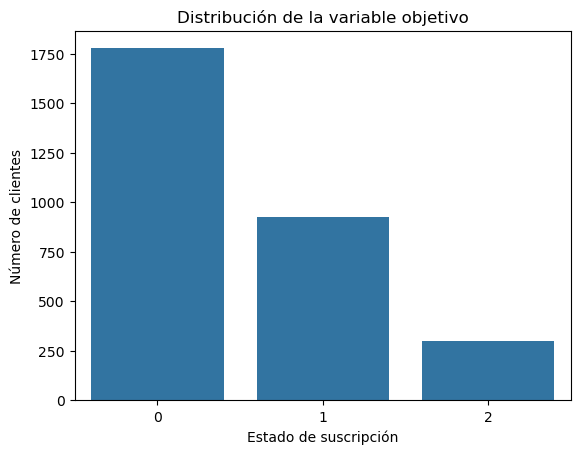

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

target = "subscription_status"

# Frecuencias 'subscription_status'
print(df[target].value_counts().sort_index())

# Visualizamos la frecuencia
plt.figure()
sns.countplot(data=df, x=target)
plt.title("Distribución de la variable objetivo")
plt.xlabel("Estado de suscripción")
plt.ylabel("Número de clientes")
plt.show()


In [6]:
# Separamos las variables numéricas y categóricas
numeric_features = df.drop(columns=[target]).select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = df.drop(columns=[target]).select_dtypes(include=["object", "category"]).columns.tolist()

print("Variables numéricas:")
print(numeric_features)

print("\nVariables categóricas:")
print(categorical_features)

Variables numéricas:
['api_response_time_ms', 'monthly_ip_variation', 'avg_network_latency', 'unique_active_devices', 'days_since_app_update', 'internal_engagement_score', 'nps_satisfaction_score', 'monthly_usage_frequency', 'open_support_tickets', 'promotional_discount_pct', 'current_subscription_tier', 'customer_age', 'declared_income', 'virtual_wallet_balance', 'email_open_rate', 'newsletter_clicks', 'historical_purchases', 'account_age_days']

Variables categóricas:
['payment_method', 'assigned_server_region']


In [7]:
df[numeric_features].describe()

,api_response_time_ms,monthly_ip_variation,avg_network_latency,unique_active_devices,days_since_app_update,internal_engagement_score,nps_satisfaction_score,monthly_usage_frequency,open_support_tickets,promotional_discount_pct,current_subscription_tier,customer_age,declared_income,virtual_wallet_balance,email_open_rate,newsletter_clicks,historical_purchases,account_age_days
count,3000.000000,2850.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,2850.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000
mean,23.697129,3.838596,37.041505,4.193000,12.644000,47.219704,4.937333,50.830333,1.083000,10.851667,2.090175,35.475667,54572.092013,58.985223,28.436146,2.406667,2.992333,1019.233000
std,30.432795,3.096084,26.617488,2.357033,6.763075,25.285813,4.087988,29.109907,1.500287,17.276163,1.183101,10.372557,15606.170797,88.830407,16.173277,2.469275,1.725669,571.400716
min,3.427495,1.000000,1.000000,1.000000,0.000000,20.076168,0.000000,0.000000,0.000000,0.000000,1.000000,18.000000,12000.000000,0.000000,0.728125,0.000000,0.000000,36.000000
25%,11.085390,2.000000,19.876595,3.000000,9.000000,20.807521,1.000000,26.000000,0.000000,0.000000,1.000000,28.000000,43657.712500,0.000000,16.086679,0.000000,2.000000,526.000000
50%,16.446224,3.000000,29.747156,4.000000,12.000000,70.107600,2.000000,52.000000,1.000000,5.000000,2.000000,34.000000,54047.545000,18.180000,26.322919,2.000000,3.000000,1004.500000
75%,26.438698,5.000000,45.835180,5.000000,16.000000,70.880352,9.000000,77.000000,2.000000,15.000000,3.000000,42.000000,64834.170000,86.155000,38.816306,4.000000,4.000000,1520.250000
max,850.323118,20.000000,245.947726,15.000000,120.000000,100.000000,10.000000,99.000000,13.000000,95.000000,5.000000,87.000000,114573.550000,694.760000,92.726462,14.000000,12.000000,2019.000000


In [8]:
df[categorical_features].describe()

,payment_method,assigned_server_region
count,3000,3000
unique,4,40
top,PayPal,Region_19
freq,763,91


In [9]:
# Media agrupada por 'subscription_status'
media_por_clase = df.groupby(target)[numeric_features].mean().T
media_por_clase

subscription_status,0,1,2
api_response_time_ms,15.870353,29.456723,52.490942
monthly_ip_variation,2.123369,5.099089,10.080420
avg_network_latency,23.391030,47.906394,84.715568
unique_active_devices,3.005627,5.074595,8.536913
days_since_app_update,12.770962,11.289730,16.090604
internal_engagement_score,45.400068,47.510421,57.167960
nps_satisfaction_score,4.937535,4.969730,4.835570
monthly_usage_frequency,51.059651,50.041081,51.912752
open_support_tickets,1.065279,1.097297,1.144295
promotional_discount_pct,11.018571,10.854054,9.848993


In [10]:
# Mediana agrupada por 'subscription_status'
mediana_por_clase = df.groupby(target)[numeric_features].median().T
mediana_por_clase

subscription_status,0,1,2
api_response_time_ms,12.306842,24.686273,44.585116
monthly_ip_variation,2.000000,5.000000,10.000000
avg_network_latency,22.399690,43.563135,79.135074
unique_active_devices,3.000000,5.000000,8.000000
days_since_app_update,13.000000,11.000000,13.000000
internal_engagement_score,22.023884,28.664808,73.838214
nps_satisfaction_score,2.000000,2.000000,2.000000
monthly_usage_frequency,52.000000,51.000000,53.000000
open_support_tickets,1.000000,1.000000,1.000000
promotional_discount_pct,5.000000,5.000000,5.000000


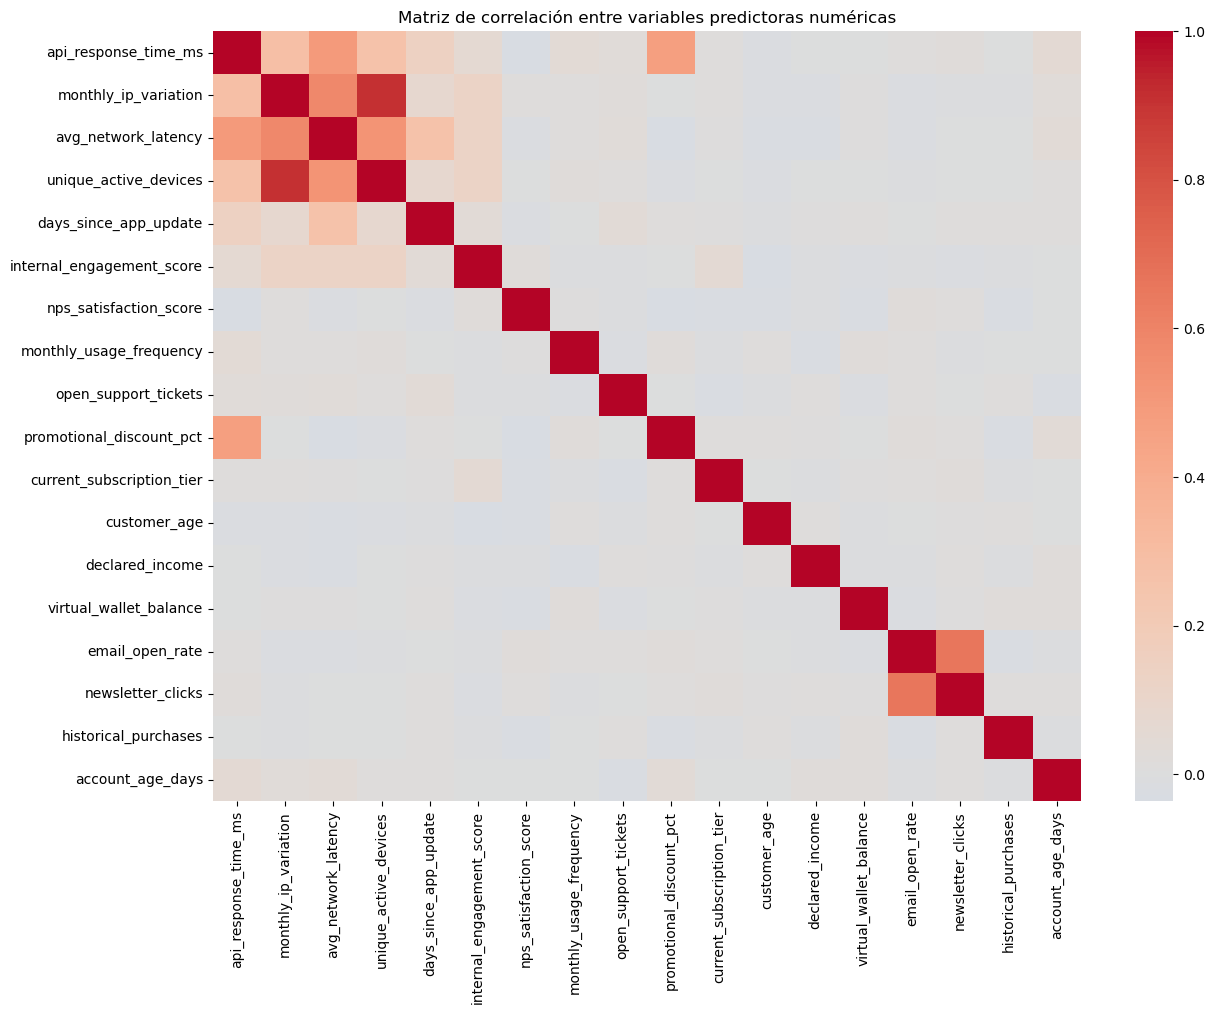

In [11]:
# Matriz de correlación
corr_features = df[numeric_features].corr()
plt.figure(figsize=(14,10))
sns.heatmap(corr_features, cmap="coolwarm", center=0)
plt.title("Matriz de correlación entre variables predictoras numéricas")
plt.show()

In [12]:
corr_target = df[numeric_features + [target]].corr()[target].drop(target).sort_values(ascending=False)

corr_target_df = pd.DataFrame({
    "Variable": corr_target.index,
    "Correlación con subscription_status": corr_target.values
})

corr_target_df

,Variable,Correlación con subscription_status
0,monthly_ip_variation,0.789736
1,avg_network_latency,0.719279
2,unique_active_devices,0.718942
3,api_response_time_ms,0.367821
4,internal_engagement_score,0.122009
5,days_since_app_update,0.058987
6,account_age_days,0.044638
7,open_support_tickets,0.016508
8,current_subscription_tier,0.015303
9,virtual_wallet_balance,0.009606


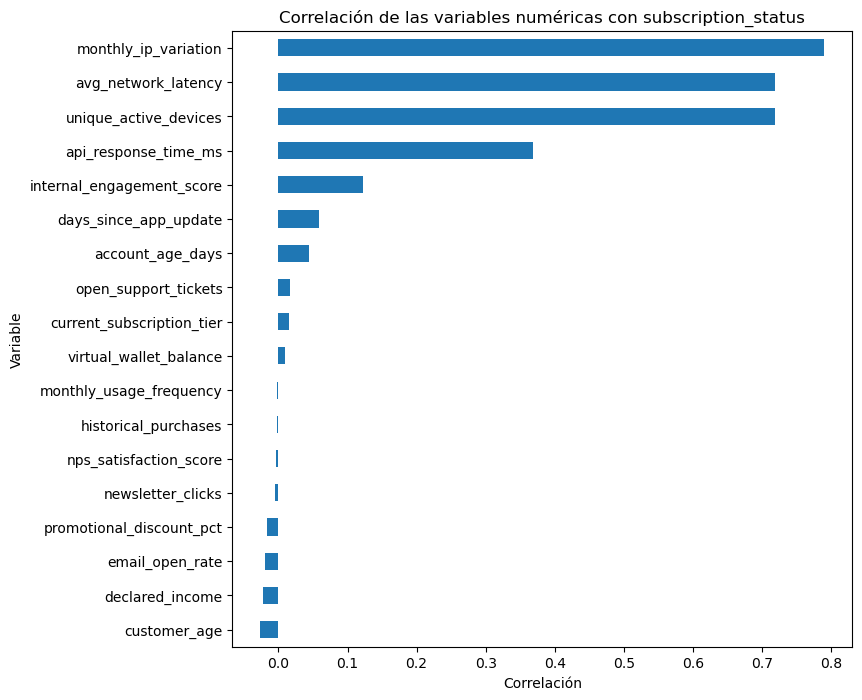

In [13]:
plt.figure(figsize=(8,8))
corr_target.sort_values().plot(kind="barh")
plt.title("Correlación de las variables numéricas con subscription_status")
plt.xlabel("Correlación")
plt.ylabel("Variable")
plt.show()

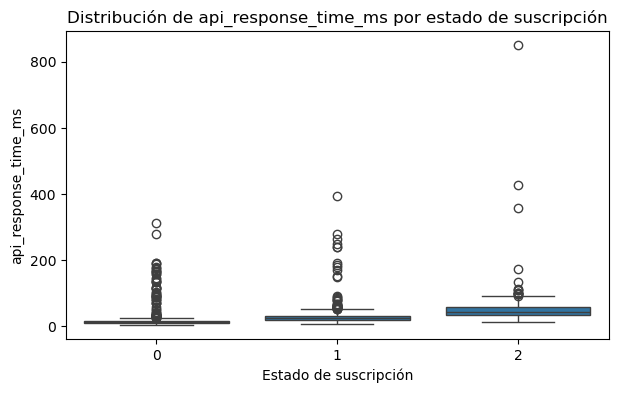

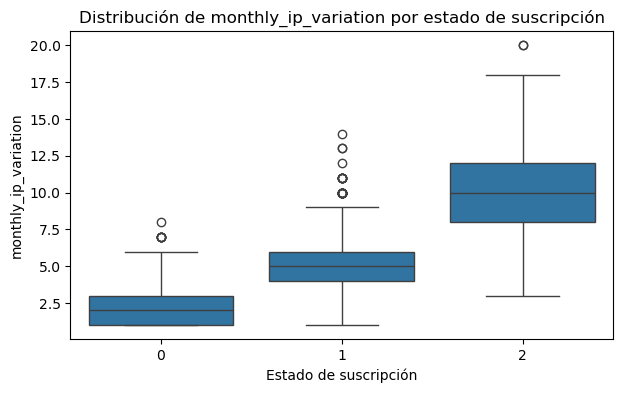

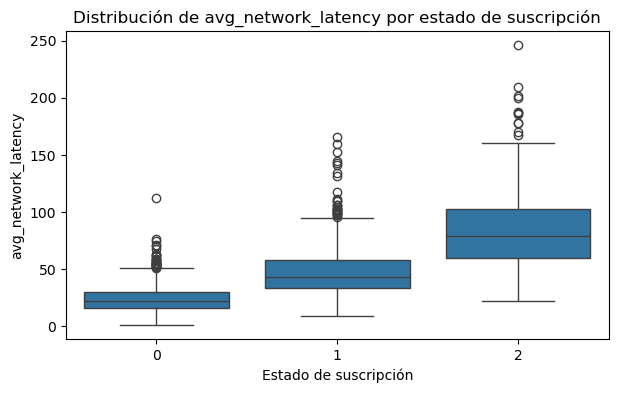

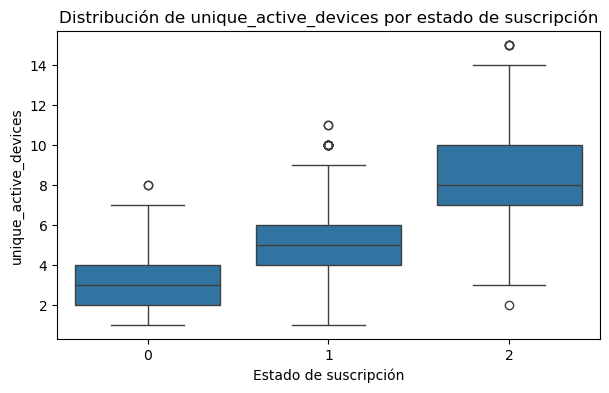

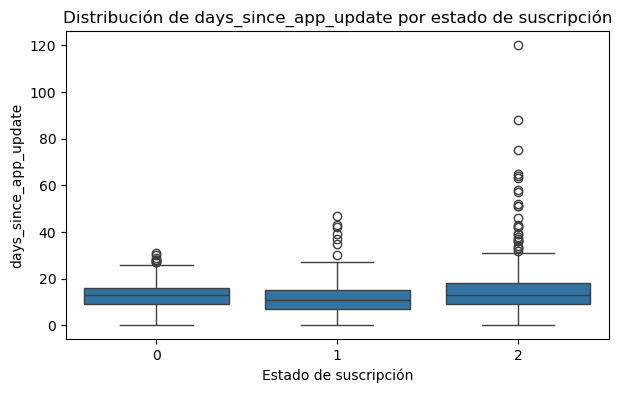

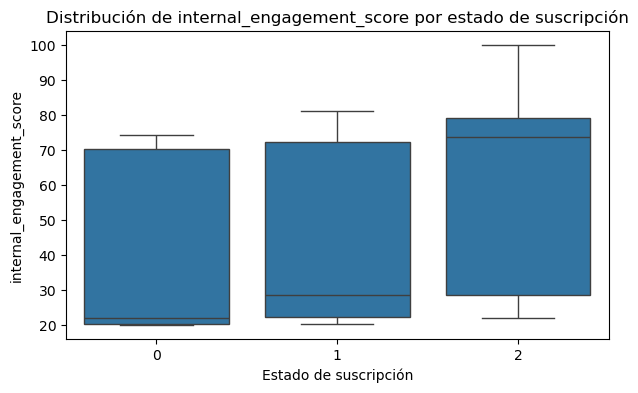

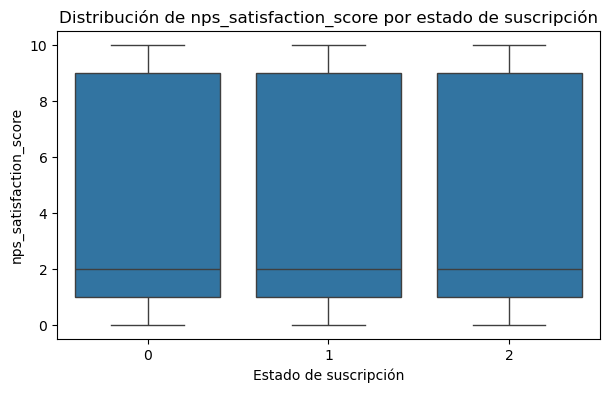

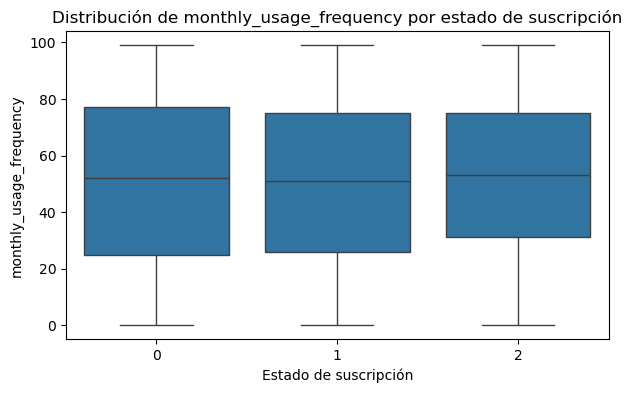

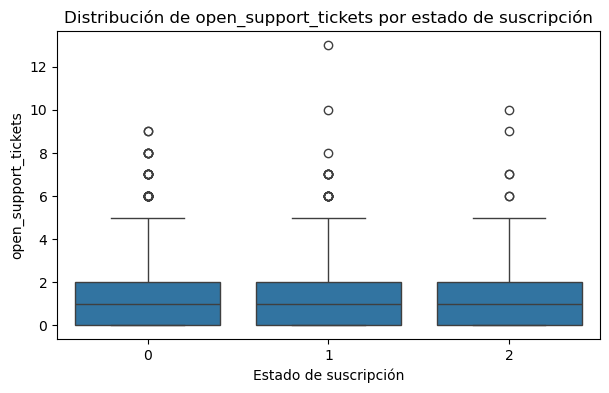

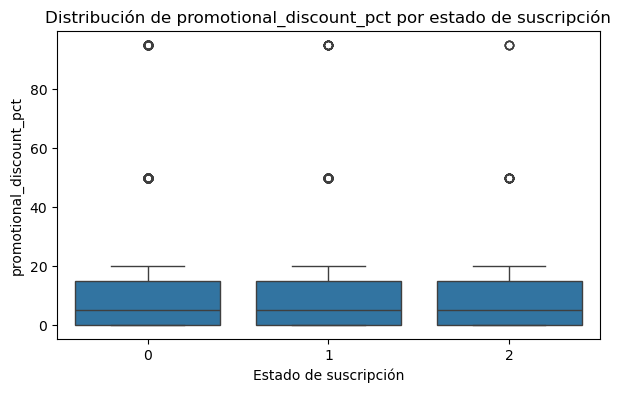

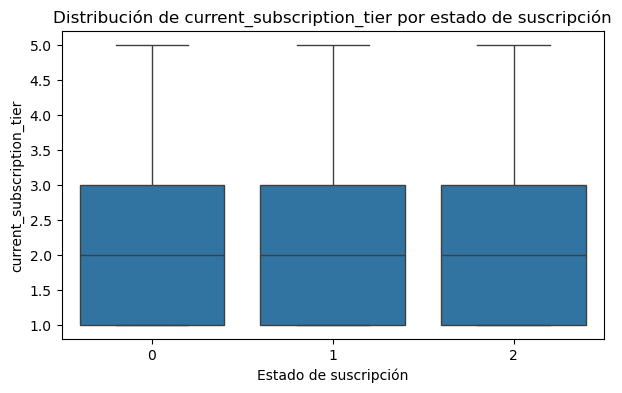

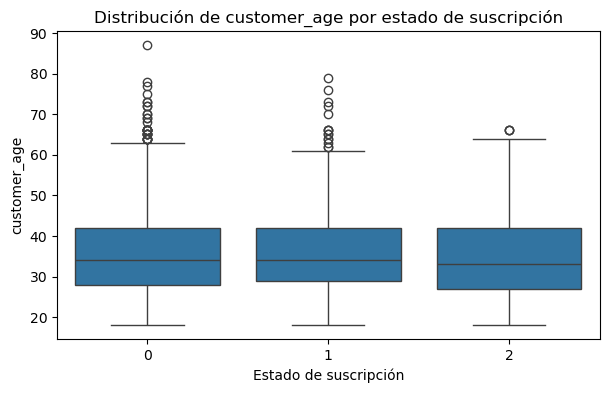

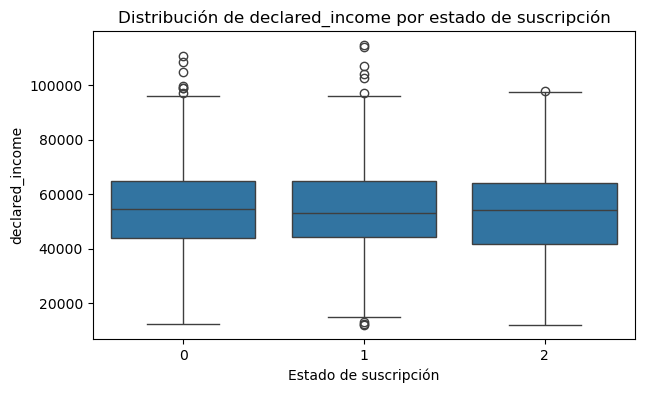

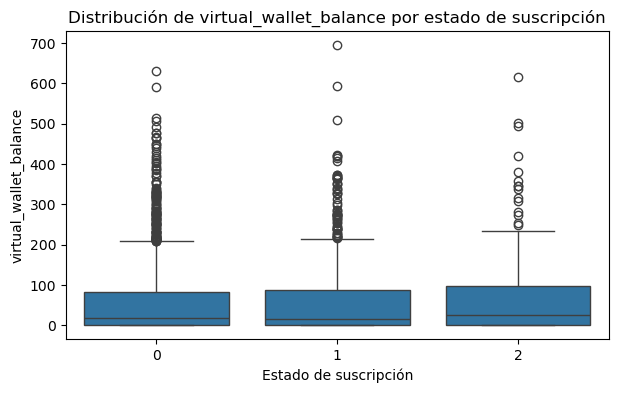

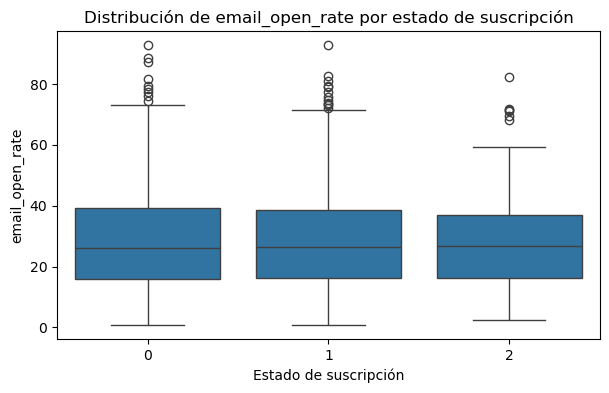

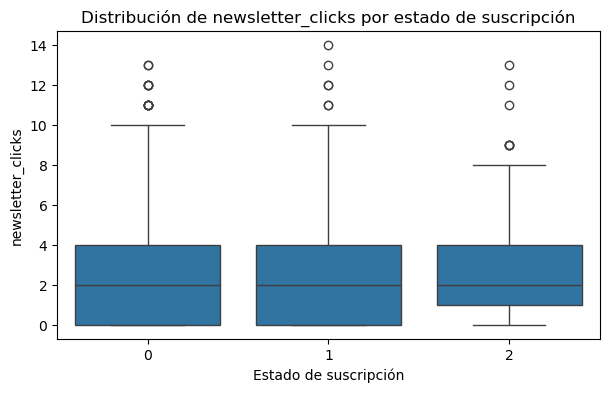

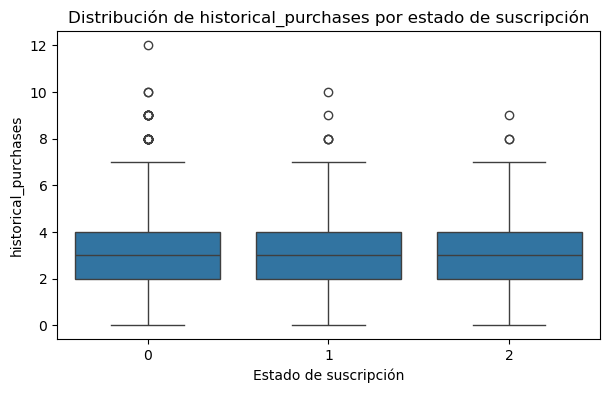

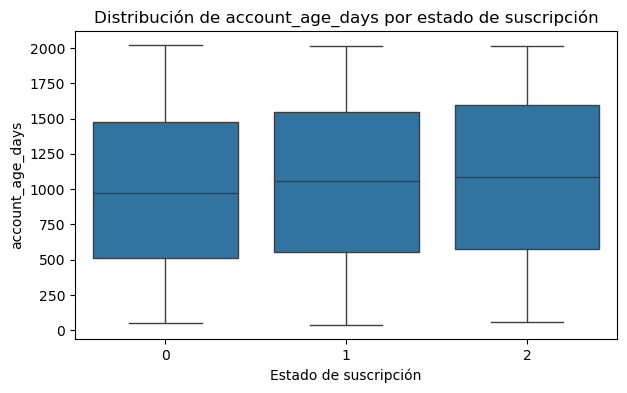

In [14]:
for col in numeric_features:
    plt.figure(figsize=(7,4))
    sns.boxplot(data=df, x=target, y=col)
    plt.title(f"Distribución de {col} por estado de suscripción")
    plt.xlabel("Estado de suscripción")
    plt.ylabel(col)
    plt.show()

In [15]:
pd.crosstab(df["payment_method"], df[target])

subscription_status,0,1,2
payment_method,,,
Bank Transfer,432,219,76
Credit Card,446,242,75
Crypto,430,250,67
PayPal,469,214,80


In [16]:
pd.crosstab(df["assigned_server_region"], df[target])

subscription_status,0,1,2
assigned_server_region,,,
Region_01,55,15,10
Region_02,34,26,8
Region_03,54,26,4
Region_04,48,17,4
Region_05,40,25,7
Region_06,40,17,7
Region_07,50,26,3
Region_08,45,29,14
Region_09,45,33,10


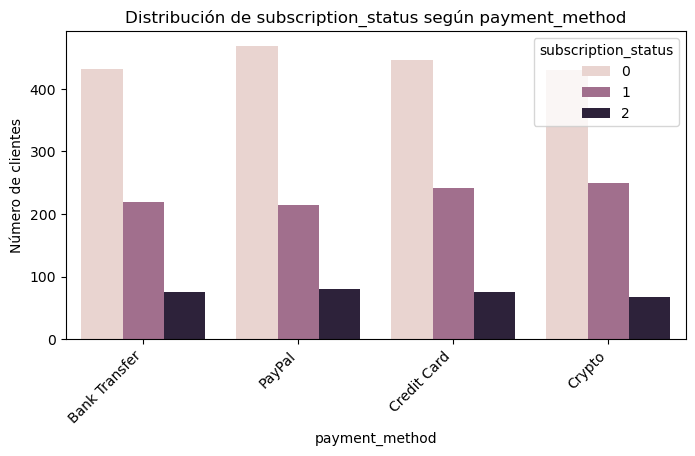

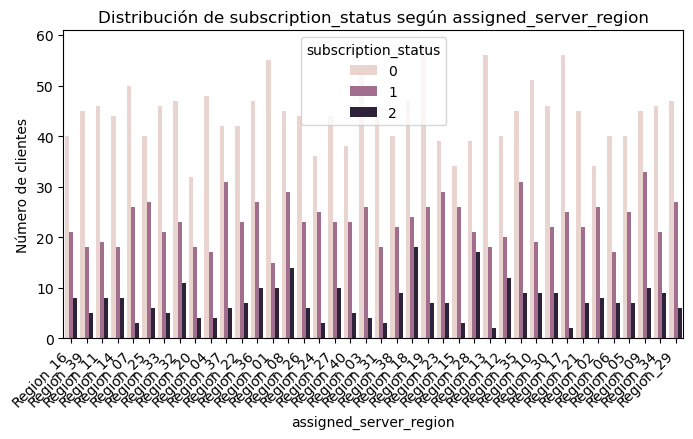

In [17]:
for col in categorical_features:
    plt.figure(figsize=(8,4))
    sns.countplot(data=df, x=col, hue=target)
    plt.title(f"Distribución de {target} según {col}")
    plt.xlabel(col)
    plt.ylabel("Número de clientes")
    plt.xticks(rotation=45, ha="right")
    plt.legend(title=target)
    plt.show()

<div style="background-color: #dff0d8; color: #3c763d; padding: 10px; border: 1px solid #d6e9c6; border-radius: 4px;">
<h4>Observaciones:</h4>  

* xxx
* xxx
* xxx

</div>

<div style="background-color: #d9edf7; color: #31708f; padding: 10px; border: 1px solid #bce8f1; border-radius: 4px;">
<h4>1.3. Análisis Crítico de Evidencia:</h4>
    
* Compara las conclusiones teóricas propuestas por la I.A. con los patrones reales detectados en el dataset. ¿Existen variables que la I.A. considera críticas pero que en este dataset muestran poca relevancia o comportamientos inesperados?
* Identifica y discute los desafíos específicos detectados: desequilibrio de clases en la variable `subscription_status`, presencia de multicolinealidad y el impacto de los *outliers*.
</div>

### Comparación entre las conclusiones teóricas de la I.A. y los patrones reales del dataset

Según la explicación teórica proporcionada por la herramienta de I.A. generativa, los indicadores más habituales de churn en empresas SaaS suelen estar relacionados con el uso del producto, el engagement, la satisfacción del cliente, el soporte técnico, las comunicaciones comerciales, la relación comercial y la calidad de la experiencia técnica. En el dataset de CloudSync Platforms, estas dimensiones aparecen representadas por variables como `monthly_usage_frequency`, `internal_engagement_score`, `nps_satisfaction_score`, `open_support_tickets`, `email_open_rate`, `newsletter_clicks`, `promotional_discount_pct`, `current_subscription_tier`, `api_response_time_ms` y `avg_network_latency`.

Al comparar la teoría con el análisis exploratorio realizado sobre el dataset, se observa que las variables más relevantes parecen estar más relacionadas con aspectos técnicos y patrones de acceso que con indicadores tradicionales de satisfacción o marketing. En particular, variables como `monthly_ip_variation`, `avg_network_latency`, `unique_active_devices` y `api_response_time_ms` destacan como variables importantes dentro del análisis. Esto sugiere que, en este caso, el abandono podría estar más vinculado a la experiencia técnica del usuario y a la forma en que accede a la plataforma que a métricas clásicas de comportamiento comercial. Variables como `avg_network_latency` y `api_response_time_ms` representan la calidad técnica del servicio, mientras que `monthly_ip_variation` y `unique_active_devices` reflejan patrones de conexión y uso desde distintos entornos o dispositivos. Por otro lado, algunas variables que la teoría SaaS suele considerar importantes parecen tener menor protagonismo en este dataset. Es el caso de `nps_satisfaction_score`, `monthly_usage_frequency`, `open_support_tickets`, `email_open_rate` y `newsletter_clicks`. Estas variables representan satisfacción declarada, frecuencia de uso, interacción con soporte y relación con comunicaciones comerciales, pero en este análisis no parecen ser las que mejor diferencian los estados de suscripción.

En conclusión, la comparación entre la teoría propuesta por la I.A. y los patrones reales del dataset muestra una coincidencia parcial. La teoría SaaS acierta al señalar la importancia de la experiencia técnica, pero en este dataset los indicadores técnicos y de acceso parecen tener más peso que variables clásicas como satisfacción, frecuencia de uso, soporte o marketing. Por tanto, en CloudSync Platforms el churn parece estar más asociado a variables de infraestructura y patrones de acceso que a indicadores tradicionales de relación con el cliente.

### Desafíos específicos detectados en el dataset

El análisis exploratorio permite identificar tres desafíos importantes que deben tenerse en cuenta antes de entrenar los modelos de clasificación: el desequilibrio de clases en la variable objetivo `subscription_status`, la presencia de multicolinealidad entre algunas variables predictoras y el posible impacto de los outliers.

En primer lugar, la variable objetivo `subscription_status` representa tres estados distintos del cliente: renovación, pausa y cancelación. En este tipo de problema, el desequilibrio de clases es especialmente relevante porque la clase más importante desde el punto de vista empresarial es la clase 2, correspondiente a la cancelación definitiva. Si esta clase tiene menor representación que las demás, un modelo podría obtener una buena exactitud global clasificando correctamente las clases mayoritarias, pero fallar en la detección de los clientes que realmente cancelan. Por ello, en la fase de modelado no será suficiente utilizar únicamente `accuracy`; será necesario analizar métricas como `recall`, `precision` y `F1-score` por clase, prestando especial atención a la clase 2. También será conveniente utilizar métricas globales más robustas ante desbalanceo, como `balanced_accuracy` o `f1_macro`.

En segundo lugar, se observa presencia de multicolinealidad entre algunas variables predictoras numéricas. La matriz de correlación muestra que determinadas variables técnicas y de patrón de acceso están relacionadas entre sí, especialmente `monthly_ip_variation`, `avg_network_latency`, `unique_active_devices` y, en menor medida, `api_response_time_ms`. Esta relación tiene sentido, ya que todas ellas describen aspectos vinculados a la infraestructura, la conexión o la forma en que el usuario accede a la plataforma. La multicolinealidad puede dificultar la interpretación individual de la importancia de cada variable, ya que varias variables pueden estar capturando información similar. Este problema afecta especialmente a modelos lineales, como la regresión logística, pero suele ser menos problemático en modelos basados en árboles y ensembles, como Random Forest o Gradient Boosting. Aun así, deberá tenerse en cuenta al interpretar la importancia de características.

En tercer lugar, los outliers pueden tener impacto en algunas variables numéricas del dataset. Variables como `api_response_time_ms`, `avg_network_latency`, `monthly_ip_variation`, `unique_active_devices`, `declared_income` o `virtual_wallet_balance` pueden presentar valores extremos. En este contexto, no conviene eliminar automáticamente estos registros, ya que algunos valores atípicos podrían representar situaciones reales de interés, como usuarios con una experiencia técnica muy negativa, patrones de acceso anómalos o perfiles comerciales diferentes. Estos casos pueden ser especialmente relevantes para predecir el churn. El impacto de los outliers dependerá del tipo de modelo utilizado. Los modelos sensibles a la escala o basados en distancias pueden verse más afectados por valores extremos, mientras que los modelos basados en árboles suelen ser más robustos. No obstante, los outliers pueden influir en la construcción de particiones y en la interpretación posterior del modelo.


<div style="background-color: #f2dede; color: #a94442; padding: 10px; border: 1px solid #ebccd1; border-radius: 4px">
<h4>Solución:</h4>
</div>

<div style="background-color: #dff0d8; color: #3c763d; padding: 10px; border: 1px solid #d6e9c6; border-radius: 4px;">
<h4>Observaciones:</h4>  



* xxx
* xxx
* xxx
 
</div>

<div style="background-color: #d9edf7; color: #31708f; padding: 10px; border: 1px solid #bce8f1; border-radius: 4px;">
<h4>1.4. Preparación y Justificación de Datos:</h4>
    
* Realiza las transformaciones necesarias para la clasificación: codificación de variables categóricas y eliminación de redundancias detectadas.
* Realiza la división Train/Test (80/20) asegurando la estratificación de la variable objetivo y utiliza la semilla `random_state=42`.

</div>

<div style="background-color: #f2dede; color: #a94442; padding: 10px; border: 1px solid #ebccd1; border-radius: 4px">
<h4>Solución:</h4>
</div>

In [18]:
# Variables categóricas detectadas
variables_categoricas = ["payment_method", "assigned_server_region"]

# Recodificación mediante One-Hot Encoding
df_encoded = pd.get_dummies(df, columns=variables_categoricas, drop_first=False, dtype=int)

Tras revisar las variables predictoras, se decide eliminar `newsletter_clicks` por redundancia conceptual con `email_open_rate`. Ambas variables miden la interacción del usuario con las comunicaciones de marketing de la empresa: `email_open_rate` recoge el porcentaje de correos abiertos, mientras que `newsletter_clicks` mide los clics realizados en enlaces de newsletters. Se conserva `email_open_rate` porque resume de forma más general el nivel de interacción con las comunicaciones enviadas.

In [19]:
# Eliminación de variables redundantes detectadas
variables_redundantes = ["newsletter_clicks"]
df_model = df_encoded.drop(columns=variables_redundantes)

In [20]:
from sklearn.model_selection import train_test_split

# Separación entre variables predictoras y variable objetivo
X = df_model.drop(columns=["subscription_status"])
y = df_model["subscription_status"]

# División Train/Test 80/20 con estratificación
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)


<div style="background-color: #dff0d8; color: #3c763d; padding: 10px; border: 1px solid #d6e9c6; border-radius: 4px;">
<h4>Observaciones:</h4>  

* xxx
* xxx
* xxx
  
</div>

<div style="background-color: #d9edf7; color: #31708f; padding: 10px; border: 1px solid #bce8f1; border-radius: 4px;">
<h4>1.5. Análisis final:</h4>

* Detalla qué herramienta de I.A. has usado y pega el/los *prompts* principales que utilizaste para obtener el marco teórico inicial.
* Explica qué respuestas de la I.A. resultaron ser interpretaciones erróneas o "alucinaciones" basadas en teoría general al contrastarlas con la realidad sintética de CloudSync.
* ¿Qué has aprendido de nuevo en este proceso de contraste? ¿Qué información has tenido que buscar más allá de las sugerencias de la I.A. o los materiales docentes para resolver los retos de este dataset?
</div>

La herramienta de I.A. generativa utilizada ha sido **ChatGPT**. También se consultó **Gemini**, pero finalmente se decidió utilizar la respuesta proporcionada por ChatGPT, ya que se ajustaba mejor al enfoque del análisis planteado en esta práctica.

El prompt utilizado fue el siguiente:

> Utiliza una herramienta de I.A. Generativa (ChatGPT, Gemini, Claude, etc.) para que te explique cuáles suelen ser, según la teoría del sector SaaS, los indicadores más comunes que predicen el abandono (*churn*) de un cliente.

### Interpretaciones erróneas de la I.A.

Al contrastar las respuestas proporcionadas por la I.A. generativa con los patrones reales observados en el dataset se detecta que algunas afirmaciones generales del sector SaaS no se cumplen claramente en este caso concreto. Una primera interpretación parcialmente errónea fue asumir que la satisfacción declarada del cliente sería uno de los principales indicadores de churn. Teóricamente, una variable como `nps_satisfaction_score` debería ayudar a diferenciar a los clientes satisfechos de los que tienen mayor riesgo de abandono. Sin embargo, en este dataset dicha variable muestra poca capacidad diferenciadora.

Algo similar ocurre con `monthly_usage_frequency`. La I.A. planteó que una menor frecuencia de uso suele ser una señal clara de abandono en SaaS. Aunque esta idea es razonable en muchos contextos reales, en CloudSync esta variable no aparece como uno de los factores más relevantes. 

También puede considerarse una interpretación débil la importancia atribuida a `open_support_tickets`. Desde la teoría, un mayor número de incidencias abiertas podría indicar frustración o problemas no resueltos, pero en este dataset esta variable no parece tener un peso destacado. 

Otro posible error teórico está relacionado con las variables de marketing, como `email_open_rate` y `newsletter_clicks`. La I.A. las identificó como indicadores de engagement y posible retención, pero en el análisis real no parecen ser variables especialmente informativas para distinguir entre renovación, pausa o cancelación. En cambio, el dataset muestra que las variables más relevantes están más relacionadas con aspectos técnicos y patrones de acceso, como `monthly_ip_variation`, `avg_network_latency`, `unique_active_devices`, `api_response_time_ms` y `assigned_server_region`. Esto confirma que la I.A. acertó parcialmente al mencionar la experiencia técnica, pero no anticipó correctamente que esta dimensión tendría un peso mucho mayor que indicadores clásicos como satisfacción, uso, soporte o marketing.

<div style="background-color: #f2dede; color: #a94442; padding: 10px; border: 1px solid #ebccd1; border-radius: 4px">
<h4>Solución:</h4>
</div>

<div style="background-color: #dff0d8; color: #3c763d; padding: 10px; border: 1px solid #d6e9c6; border-radius: 4px;">
<h4>Observaciones:</h4>  
    
* xx
* xx
* xx

</div>

### Aprendizaje del proceso de contraste

En este proceso he aprendido que las recomendaciones generales proporcionadas por una herramienta de I.A. generativa no deben aceptarse directamente como conclusiones definitivas. La I.A. puede ofrecer un marco teórico útil para iniciar el análisis, pero sus respuestas están basadas en patrones generales y no necesariamente reflejan el comportamiento específico del dataset. El contraste con los datos reales de CloudSync ha mostrado que algunas variables tradicionalmente consideradas importantes en problemas de churn no siempre son las más relevantes en todos los contextos. 

Más allá de las sugerencias de la I.A. y de los materiales docentes, ha sido necesario profundizar en cómo tratar problemas prácticos del dataset, como la codificación de variables categóricas mediante One-Hot Encoding, la interpretación de variables redundantes, la conveniencia de no eliminar variables únicamente por baja correlación y la importancia de realizar una división Train/Test estratificada para conservar la proporción de clases. Además, ha sido necesario reflexionar sobre qué métricas serán más adecuadas para evaluar los modelos. 

En resumen, el principal aprendizaje ha sido que la I.A. generativa resulta útil como punto de partida para formular hipótesis, pero el análisis final debe basarse en la evidencia proporcionada por los datos. 

## 2 . Entrenamiento y Evaluación de Modelos Base (1 punto)

<div style="background-color: #d9edf7; color: #31708f; padding: 10px; border: 1px solid #bce8f1; border-radius: 4px;">
<h4>Implementación:</h4>

1. Entrena con el conjunto de datos de entrenamiento y valida con el conjunto de datos de validación los siguientes modelos base (Guarda las predicciones para su uso más adelante):
   * Regresión Logística (`LogisticRegression`)
   * Árbol de Decisión (`DecisionTreeClassifier`)
   * K vecinos cercanos (`KNeighborsClassifier`)
   * Clasificador Naïves-Bayes (`GaussianNB`)
2. Para cada modelo, reporta las métricas obtenidas de la validación que consideres necesarias.
3. **Análisis Crítico:** Comenta brevemente el rendimiento de modelos base. ¿Cuál de las métricas consideras más informativa para evaluar el rendimiento y por qué? Justifica tu respuesta.
   
</div>

<div style="background-color: #f2dede; color: #a94442; padding: 10px; border: 1px solid #ebccd1; border-radius: 4px">
<h4>Solución:</h4>

</div>

In [21]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

import pandas as pd

resultados_modelos = {}
predicciones_modelos = {}

In [22]:
logistic_model = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        max_iter=1000,
        random_state=42,
        class_weight="balanced"
    ))
])

logistic_model.fit(X_train, y_train)

y_pred_logistic = logistic_model.predict(X_test)

predicciones_modelos["Logistic Regression"] = y_pred_logistic

resultados_modelos["Logistic Regression"] = {
    "accuracy": accuracy_score(y_test, y_pred_logistic),
    "balanced_accuracy": balanced_accuracy_score(y_test, y_pred_logistic),
    "precision_macro": precision_score(y_test, y_pred_logistic, average="macro"),
    "recall_macro": recall_score(y_test, y_pred_logistic, average="macro"),
    "f1_macro": f1_score(y_test, y_pred_logistic, average="macro"),
    "recall_clase_2": recall_score(y_test, y_pred_logistic, labels=[2], average=None)[0],
    "f1_clase_2": f1_score(y_test, y_pred_logistic, labels=[2], average=None)[0]
}

print("Métricas - Logistic Regression")
display(pd.DataFrame(resultados_modelos["Logistic Regression"], index=[0]))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_logistic))

print("\nMatriz de confusión:")
print(confusion_matrix(y_test, y_pred_logistic))

Métricas - Logistic Regression


,accuracy,balanced_accuracy,precision_macro,recall_macro,f1_macro,recall_clase_2,f1_clase_2
0,0.836667,0.827346,0.769383,0.827346,0.790449,0.883333,0.731034



Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.90      0.92       355
           1       0.75      0.70      0.72       185
           2       0.62      0.88      0.73        60

    accuracy                           0.84       600
   macro avg       0.77      0.83      0.79       600
weighted avg       0.85      0.84      0.84       600


Matriz de confusión:
[[320  35   0]
 [ 24 129  32]
 [  0   7  53]]


In [23]:
# Modelo: Árbol de Decisión
decision_tree_model = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("model", DecisionTreeClassifier(
        random_state=42,
        class_weight="balanced"
    ))
])

# Entrenamiento
decision_tree_model.fit(X_train, y_train)

# Predicción
y_pred_tree = decision_tree_model.predict(X_test)

# Guardar predicciones
predicciones_modelos["Decision Tree"] = y_pred_tree

# Métricas
resultados_modelos["Decision Tree"] = {
    "accuracy": accuracy_score(y_test, y_pred_tree),
    "balanced_accuracy": balanced_accuracy_score(y_test, y_pred_tree),
    "precision_macro": precision_score(y_test, y_pred_tree, average="macro"),
    "recall_macro": recall_score(y_test, y_pred_tree, average="macro"),
    "f1_macro": f1_score(y_test, y_pred_tree, average="macro"),
    "recall_clase_2": recall_score(y_test, y_pred_tree, labels=[2], average=None)[0],
    "f1_clase_2": f1_score(y_test, y_pred_tree, labels=[2], average=None)[0]
}

print("Métricas - Decision Tree")
display(pd.DataFrame(resultados_modelos["Decision Tree"], index=[0]))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_tree))

print("\nMatriz de confusión:")
print(confusion_matrix(y_test, y_pred_tree))

Métricas - Decision Tree


,accuracy,balanced_accuracy,precision_macro,recall_macro,f1_macro,recall_clase_2,f1_clase_2
0,0.793333,0.769194,0.729166,0.769194,0.745833,0.783333,0.691176



Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.86      0.88       355
           1       0.67      0.66      0.67       185
           2       0.62      0.78      0.69        60

    accuracy                           0.79       600
   macro avg       0.73      0.77      0.75       600
weighted avg       0.80      0.79      0.80       600


Matriz de confusión:
[[307  46   2]
 [ 36 122  27]
 [  0  13  47]]


In [24]:
# Modelo: K-Nearest Neighbors
knn_model = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", KNeighborsClassifier(
        n_neighbors=5
    ))
])

# Entrenamiento
knn_model.fit(X_train, y_train)

# Predicción
y_pred_knn = knn_model.predict(X_test)

# Guardar predicciones
predicciones_modelos["KNN"] = y_pred_knn

# Métricas
resultados_modelos["KNN"] = {
    "accuracy": accuracy_score(y_test, y_pred_knn),
    "balanced_accuracy": balanced_accuracy_score(y_test, y_pred_knn),
    "precision_macro": precision_score(y_test, y_pred_knn, average="macro"),
    "recall_macro": recall_score(y_test, y_pred_knn, average="macro"),
    "f1_macro": f1_score(y_test, y_pred_knn, average="macro"),
    "recall_clase_2": recall_score(y_test, y_pred_knn, labels=[2], average=None)[0],
    "f1_clase_2": f1_score(y_test, y_pred_knn, labels=[2], average=None)[0]
}

print("Métricas - KNN")
display(pd.DataFrame(resultados_modelos["KNN"], index=[0]))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_knn))

print("\nMatriz de confusión:")
print(confusion_matrix(y_test, y_pred_knn))

C:\Users\Victor\anaconda3\envs\env_891_20252_pec4\lib\site-packages\threadpoolctl.py:1214: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)


Métricas - KNN


,accuracy,balanced_accuracy,precision_macro,recall_macro,f1_macro,recall_clase_2,f1_clase_2
0,0.668333,0.508201,0.713763,0.508201,0.541815,0.266667,0.415584



Classification Report:
              precision    recall  f1-score   support

           0       0.71      0.90      0.80       355
           1       0.49      0.36      0.41       185
           2       0.94      0.27      0.42        60

    accuracy                           0.67       600
   macro avg       0.71      0.51      0.54       600
weighted avg       0.67      0.67      0.64       600


Matriz de confusión:
[[318  37   0]
 [117  67   1]
 [ 10  34  16]]


In [25]:
# Modelo: Gaussian Naive Bayes
naive_bayes_model = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", GaussianNB())
])

# Entrenamiento
naive_bayes_model.fit(X_train, y_train)

# Predicción
y_pred_nb = naive_bayes_model.predict(X_test)

# Guardar predicciones
predicciones_modelos["GaussianNB"] = y_pred_nb

# Métricas
resultados_modelos["GaussianNB"] = {
    "accuracy": accuracy_score(y_test, y_pred_nb),
    "balanced_accuracy": balanced_accuracy_score(y_test, y_pred_nb),
    "precision_macro": precision_score(y_test, y_pred_nb, average="macro"),
    "recall_macro": recall_score(y_test, y_pred_nb, average="macro"),
    "f1_macro": f1_score(y_test, y_pred_nb, average="macro"),
    "recall_clase_2": recall_score(y_test, y_pred_nb, labels=[2], average=None)[0],
    "f1_clase_2": f1_score(y_test, y_pred_nb, labels=[2], average=None)[0]
}

print("Métricas - GaussianNB")
display(pd.DataFrame(resultados_modelos["GaussianNB"], index=[0]))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_nb))

print("\nMatriz de confusión:")
print(confusion_matrix(y_test, y_pred_nb))

Métricas - GaussianNB


,accuracy,balanced_accuracy,precision_macro,recall_macro,f1_macro,recall_clase_2,f1_clase_2
0,0.63,0.611769,0.552151,0.611769,0.562692,0.65,0.443182



Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.70      0.77       355
           1       0.46      0.48      0.47       185
           2       0.34      0.65      0.44        60

    accuracy                           0.63       600
   macro avg       0.55      0.61      0.56       600
weighted avg       0.68      0.63      0.65       600


Matriz de confusión:
[[250  83  22]
 [ 41  89  55]
 [  0  21  39]]


In [26]:
resultados_base_df = pd.DataFrame(resultados_modelos).T
resultados_base_df

,accuracy,balanced_accuracy,precision_macro,recall_macro,f1_macro,recall_clase_2,f1_clase_2
Logistic Regression,0.836667,0.827346,0.769383,0.827346,0.790449,0.883333,0.731034
Decision Tree,0.793333,0.769194,0.729166,0.769194,0.745833,0.783333,0.691176
KNN,0.668333,0.508201,0.713763,0.508201,0.541815,0.266667,0.415584
GaussianNB,0.630000,0.611769,0.552151,0.611769,0.562692,0.650000,0.443182


### Métricas utilizadas

- **Accuracy**: porcentaje total de predicciones correctas.

- **Balanced accuracy**: accuracy ajustada para tener en cuenta el posible desequilibrio entre clases.

- **Precision macro**: media de la precisión obtenida en cada clase.

- **Recall macro**: media del recall obtenido en cada clase.

- **F1-score macro**: media del F1-score de todas las clases.

- **Recall clase 2**: capacidad del modelo para detectar correctamente los clientes que cancelan.

- **F1-score clase 2**: equilibrio entre precisión y recall para la clase de cancelación.

- **Classification report**: resumen de precision, recall, F1-score y soporte por clase.

- **Matriz de confusión**: tabla que muestra aciertos y errores entre clases reales y predichas.

Se incluyen `recall_clase_2` y `f1_clase_2` porque la clase 2 representa la cancelación definitiva del cliente, que es el evento más crítico para la empresa. El `recall_clase_2` permite medir si el modelo detecta correctamente a los clientes que realmente van a cancelar, reduciendo el riesgo de falsos negativos. El `f1_clase_2` complementa esta información al evaluar el equilibrio entre detectar cancelaciones y no generar un número excesivo de falsas alarmas.

### Análisis crítico de los modelos base

Al comparar los modelos base, se observa que no todos se comportan igual ante este problema. La **Regresión Logística** es el modelo que obtiene mejores resultados entre los clasificadores base. Destaca especialmente porque consigue detectar muy bien la clase 2, correspondiente a los clientes que cancelan, que es precisamente la clase más importante desde el punto de vista del negocio.

El **Árbol de Decisión** también ofrece un rendimiento aceptable, aunque algo inferior al de la Regresión Logística. Es capaz de identificar bastantes casos de cancelación, pero parece menos estable y tiene peores resultados globales.

El modelo **KNN** es el que peor funciona para este caso. Aunque consigue cierta accuracy, detecta muy mal la clase 2. Esto lo hace poco adecuado para el objetivo del problema, ya que dejaría escapar muchos clientes que realmente van a cancelar.

Por su parte, **Gaussian Naive Bayes** mejora a KNN en la detección de cancelaciones, pero su rendimiento general sigue siendo limitado. Probablemente esto se debe a que este modelo parte de una hipótesis de independencia entre variables que no encaja demasiado bien con este dataset, donde hay variables técnicas y de acceso que están relacionadas entre sí.

La métrica más informativa para comparar los modelos es el **F1-score macro**. Esta métrica es adecuada porque combina precisión y recall y calcula la media dando el mismo peso a cada clase. Esto es importante en este problema, ya que `subscription_status` es una variable multiclase y la clase 2, correspondiente a la cancelación definitiva, no debe quedar eclipsada por las clases mayoritarias. 

En resumen, entre los modelos base, la **Regresión Logística** parece ser la opción más sólida, especialmente por su capacidad para detectar la clase de cancelación. Aun así, será necesario comparar estos resultados con modelos ensemble para comprobar si métodos más avanzados consiguen mejorar el rendimiento.

<div style="background-color: #dff0d8; color: #3c763d; padding: 10px; border: 1px solid #d6e9c6; border-radius: 4px;">
<h4>Observaciones y Análisis Crítico:</h4>

* xxx
* xxx
* xxx

</div>

## 3 . Combinación paralela de clasificadores de base similar: Bagging (1.5 puntos)

<div style="background-color: #d9edf7; color: #31708f; padding: 10px; border: 1px solid #bce8f1; border-radius: 4px;">
<h4>Implementación:</h4>

1. Implementa `RandomForestClassifier`.
2. Realiza una búsqueda y ajuste (tuning) de hiperparámetros clave (n_estimators, max_depth, max_features) utilizando validación cruzada (ej., GridSearchCV o RandomizedSearchCV con 5-CV). Define un rango de búsqueda razonable para cada hiperparámetro y usa la métrica que justificaste como más informativa en el punto anterior para la optimización.
3. Reporta los mejores hiperparámetros encontrados y el score de validación cruzada obtenido con ellos.
   
</div>

<div style="background-color: #f2dede; color: #a94442; padding: 10px; border: 1px solid #ebccd1; border-radius: 4px">
<h4>Solución:</h4>
</div>

In [27]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold

# Pipeline con imputación + Random Forest
rf_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("model", RandomForestClassifier(
        random_state=42,
        class_weight="balanced"
    ))
])

# Rango de hiperparámetros a probar
param_grid_rf = {
    "model__n_estimators": [100, 200, 300],
    "model__max_depth": [None, 5, 10, 20],
    "model__max_features": ["sqrt", "log2", None]
}

# Validación cruzada estratificada 5-fold
cv_5 = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# GridSearchCV
grid_search_rf = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=param_grid_rf,
    scoring="f1_macro",
    cv=cv_5,
    n_jobs=-1
)

# Entrenamiento de la búsqueda
grid_search_rf.fit(X_train, y_train)

print("Mejores hiperparámetros encontrados:")
print(grid_search_rf.best_params_)

print("\nMejor F1-score macro medio en validación cruzada:")
print(grid_search_rf.best_score_)

Mejores hiperparámetros encontrados:
{'model__max_depth': 10, 'model__max_features': 'sqrt', 'model__n_estimators': 300}

Mejor F1-score macro medio en validación cruzada:
0.819075737968509


<div style="background-color: #dff0d8; color: #3c763d; padding: 10px; border: 1px solid #d6e9c6; border-radius: 4px;">
<h4>Análisis:</h4>  

* xxx
* xxx
* xxx
</div>

<div style="background-color: #d9edf7; color: #31708f; padding: 10px; border: 1px solid #bce8f1; border-radius: 4px;">
<h4>Implementación:</h4>

4. Valida (con el conjunto de datos de validación) el modelo Random Forest final (entrenado con los mejores hiperparámetros sobre todo el set de entrenamiento).
5. Muestra un gráfico de la importancia de las características (feature_importance_) del modelo final
6. **Análisis Crítico:** Compara el rendimiento de tu Random Forest optimizado con los modelos base (refiérete a los valores específicos de las métricas que obtuviste). ¿Logró RF una mejora sustancial, especialmente en las clases minoritarias? Analiza tu gráfico de importancia de características: ¿Qué variables parecen ser las más relevantes según RF? ¿Tiene sentido este resultado? ¿Identifica RF algunas de las variables categóricas que se habían identificado como importantes?
   
</div>

<div style="background-color: #f2dede; color: #a94442; padding: 10px; border: 1px solid #ebccd1; border-radius: 4px">
<h4>Solución:</h4>
</div>

In [28]:
# Mejor modelo Random Forest obtenido con GridSearchCV
best_rf_model = grid_search_rf.best_estimator_

# Predicción sobre el conjunto de validación/test
y_pred_rf_final = best_rf_model.predict(X_test)

# Guardar predicciones para uso posterior
predicciones_modelos["Random Forest Final"] = y_pred_rf_final

# Métricas del modelo final
resultados_modelos["Random Forest Final"] = {
    "accuracy": accuracy_score(y_test, y_pred_rf_final),
    "balanced_accuracy": balanced_accuracy_score(y_test, y_pred_rf_final),
    "precision_macro": precision_score(y_test, y_pred_rf_final, average="macro"),
    "recall_macro": recall_score(y_test, y_pred_rf_final, average="macro"),
    "f1_macro": f1_score(y_test, y_pred_rf_final, average="macro"),
    "recall_clase_2": recall_score(y_test, y_pred_rf_final, labels=[2], average=None)[0],
    "f1_clase_2": f1_score(y_test, y_pred_rf_final, labels=[2], average=None)[0]
}

print("Métricas - Random Forest Final")
display(pd.DataFrame(resultados_modelos["Random Forest Final"], index=[0]))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf_final))

print("\nMatriz de confusión:")
print(confusion_matrix(y_test, y_pred_rf_final))

Métricas - Random Forest Final


,accuracy,balanced_accuracy,precision_macro,recall_macro,f1_macro,recall_clase_2,f1_clase_2
0,0.881667,0.862145,0.84811,0.862145,0.854597,0.833333,0.819672



Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.91      0.93       355
           1       0.79      0.84      0.81       185
           2       0.81      0.83      0.82        60

    accuracy                           0.88       600
   macro avg       0.85      0.86      0.85       600
weighted avg       0.89      0.88      0.88       600


Matriz de confusión:
[[323  32   0]
 [ 17 156  12]
 [  0  10  50]]


In [29]:
# Extraer el modelo Random Forest del pipeline final
rf_final = best_rf_model.named_steps["model"]

# Obtener importancias
feature_importances = pd.DataFrame({
    "Variable": X_train.columns,
    "Importancia": rf_final.feature_importances_
})

# Ordenar de mayor a menor importancia
feature_importances = feature_importances.sort_values(
    by="Importancia",
    ascending=False
)


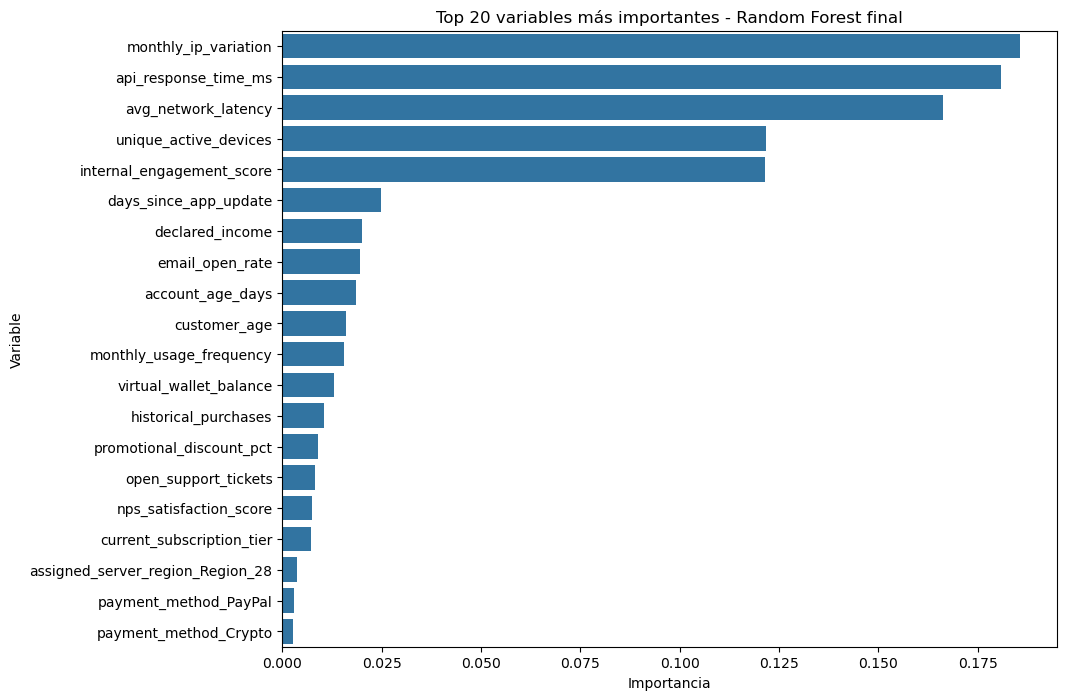

In [30]:
plt.figure(figsize=(10, 8))

sns.barplot(
    data=feature_importances.head(20),
    x="Importancia",
    y="Variable"
)

plt.title("Top 20 variables más importantes - Random Forest final")
plt.xlabel("Importancia")
plt.ylabel("Variable")
plt.show()

Al comparar el **Random Forest final** con los modelos base, se observa que mejora claramente el rendimiento general. Frente a modelos como la Regresión Logística, el Árbol de Decisión, KNN o GaussianNB, el Random Forest consigue un resultado más equilibrado y sólido en prácticamente todas las métricas globales. La mejora se nota especialmente en el `f1_macro`, que resume mejor el comportamiento del modelo en un problema multiclase, ya que no se centra únicamente en la clase mayoritaria. En cuanto a las clases minoritarias, el Random Forest también ofrece un buen resultado: en la clase 2, correspondiente a los clientes que cancelan, consigue identificar la mayoría de los casos reales y mantiene un buen equilibrio entre recall y precisión. Aunque la Regresión Logística detectaba ligeramente más cancelaciones, Random Forest comete menos errores en conjunto y ofrece un rendimiento más compensado. Por tanto, sí puede considerarse que Random Forest supone una mejora sustancial, sobre todo a nivel global y en la estabilidad del modelo.

En el gráfico de importancia de características, las variables más relevantes según Random Forest son principalmente `monthly_ip_variation`, `api_response_time_ms`, `avg_network_latency`, `unique_active_devices` e `internal_engagement_score`. Este resultado tiene sentido porque coincide con lo observado en el análisis exploratorio: las variables técnicas y de patrón de acceso parecen ser las que mejor explican el comportamiento de los clientes. Aspectos como la latencia, el tiempo de respuesta de la API, el uso desde distintos dispositivos o la variación de IPs pueden estar relacionados con problemas técnicos, accesos irregulares o una peor experiencia de usuario. Respecto a las variables categóricas, Random Forest sí identifica alguna región de servidor como relevante, especialmente `assigned_server_region_Region_28`, aunque con una importancia mucho menor que las variables numéricas principales. Esto encaja con el EDA, donde algunas regiones parecían tener más relación con la cancelación. En cambio, las variables de método de pago aparecen con menos peso, por lo que parecen aportar menos información al modelo.

<div style="background-color: #dff0d8; color: #3c763d; padding: 10px; border: 1px solid #d6e9c6; border-radius: 4px;">
<h4>Observaciones y Análisis Crítico:</h4>  

* xxx
* xxx
* xxx

</div>

## 4 . Combinación paralela de clasificadores de base similar: Boosting (1.5 puntos)

<div style="background-color: #d9edf7; color: #31708f; padding: 10px; border: 1px solid #bce8f1; border-radius: 4px;">
<h4>Implementación:</h4>

1. Implementa `GradientBoostingClassifier`.
2. Realiza una búsqueda y ajuste (tuning) de hiperparámetros clave utilizando validación cruzada. Define un rango de búsqueda razonable para cada hiperparámetro y usa la métrica F1 seleccionada.
3. Reporta los mejores hiperparámetros encontrados y el score de validación cruzada obtenido con ellos.
   
</div>

<div style="background-color: #f2dede; color: #a94442; padding: 10px; border: 1px solid #ebccd1; border-radius: 4px">
<h4>Solución:</h4>
</div>

In [31]:
from sklearn.ensemble import GradientBoostingClassifier

# Pipeline con imputación + Gradient Boosting
gb_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("model", GradientBoostingClassifier(
        random_state=42
    ))
])

# Rango de hiperparámetros a probar
param_grid_gb = {
    "model__n_estimators": [100, 200, 300],
    "model__learning_rate": [0.01, 0.05, 0.1],
    "model__max_depth": [2, 3, 5],
    "model__subsample": [0.8, 1.0]
}

# Validación cruzada estratificada 5-fold
cv_5 = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# GridSearchCV
grid_search_gb = GridSearchCV(
    estimator=gb_pipeline,
    param_grid=param_grid_gb,
    scoring="f1_macro",
    cv=cv_5,
    n_jobs=-1
)

# Entrenamiento de la búsqueda
grid_search_gb.fit(X_train, y_train)

print("Mejores hiperparámetros encontrados:")
print(grid_search_gb.best_params_)

print("\nMejor F1-score macro medio en validación cruzada:")
print(grid_search_gb.best_score_)

Mejores hiperparámetros encontrados:
{'model__learning_rate': 0.1, 'model__max_depth': 3, 'model__n_estimators': 100, 'model__subsample': 0.8}

Mejor F1-score macro medio en validación cruzada:
0.8296995278107776


<div style="background-color: #dff0d8; color: #3c763d; padding: 10px; border: 1px solid #d6e9c6; border-radius: 4px;">
<h4>Análisis:</h4>  

* xxx
* xxx
* xxx

</div>

<div style="background-color: #d9edf7; color: #31708f; padding: 10px; border: 1px solid #bce8f1; border-radius: 4px;">
<h4>Implementación:</h4>

4. Valida (con el conjunto de datos de validación) el modelo final.
5. Muestra un gráfico de la importancia de las características de dicho modelo
6. **Análisis Crítico:** Compara el rendimiento de tu Gradient Boosting optimizado con los modelos anteriores. ¿Logró una mejora sustancial? Analiza tu gráfico de importancia de características: ¿Existen diferencias notables en el ranking o en las variables consideradas más importantes por los modelos boosting en comparación con Random Forest
   
</div>

<div style="background-color: #f2dede; color: #a94442; padding: 10px; border: 1px solid #ebccd1; border-radius: 4px">
<h4>Solución:</h4>
</div>

In [32]:
# Mejor modelo Gradient Boosting obtenido con GridSearchCV
best_gb_model = grid_search_gb.best_estimator_

# Predicción sobre el conjunto de validación/test
y_pred_gb_final = best_gb_model.predict(X_test)

# Guardar predicciones para uso posterior
predicciones_modelos["Gradient Boosting Final"] = y_pred_gb_final

# Métricas del modelo final
resultados_modelos["Gradient Boosting Final"] = {
    "accuracy": accuracy_score(y_test, y_pred_gb_final),
    "balanced_accuracy": balanced_accuracy_score(y_test, y_pred_gb_final),
    "precision_macro": precision_score(y_test, y_pred_gb_final, average="macro"),
    "recall_macro": recall_score(y_test, y_pred_gb_final, average="macro"),
    "f1_macro": f1_score(y_test, y_pred_gb_final, average="macro"),
    "recall_clase_2": recall_score(y_test, y_pred_gb_final, labels=[2], average=None)[0],
    "f1_clase_2": f1_score(y_test, y_pred_gb_final, labels=[2], average=None)[0]
}

print("Métricas - Gradient Boosting Final")
display(pd.DataFrame(resultados_modelos["Gradient Boosting Final"], index=[0]))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_gb_final))

print("\nMatriz de confusión:")
print(confusion_matrix(y_test, y_pred_gb_final))

Métricas - Gradient Boosting Final


,accuracy,balanced_accuracy,precision_macro,recall_macro,f1_macro,recall_clase_2,f1_clase_2
0,0.886667,0.856031,0.852449,0.856031,0.854221,0.816667,0.809917



Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.94      0.94       355
           1       0.82      0.82      0.82       185
           2       0.80      0.82      0.81        60

    accuracy                           0.89       600
   macro avg       0.85      0.86      0.85       600
weighted avg       0.89      0.89      0.89       600


Matriz de confusión:
[[332  23   0]
 [ 22 151  12]
 [  0  11  49]]


In [33]:
# Extraer el modelo Gradient Boosting del pipeline final
gb_final = best_gb_model.named_steps["model"]

# Obtener importancias
feature_importances_gb = pd.DataFrame({
    "Variable": X_train.columns,
    "Importancia": gb_final.feature_importances_
})

# Ordenar de mayor a menor importancia
feature_importances_gb = feature_importances_gb.sort_values(
    by="Importancia",
    ascending=False
)

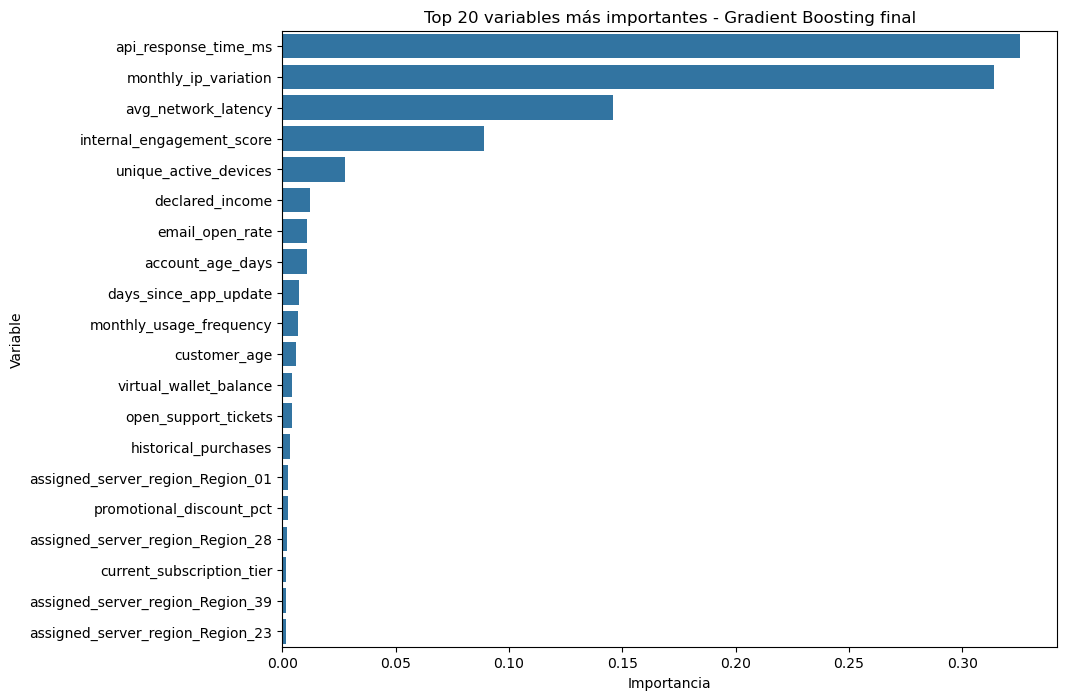

In [34]:
plt.figure(figsize=(10, 8))

sns.barplot(
    data=feature_importances_gb.head(20),
    x="Importancia",
    y="Variable"
)

plt.title("Top 20 variables más importantes - Gradient Boosting final")
plt.xlabel("Importancia")
plt.ylabel("Variable")
plt.show()

Al comparar el **Gradient Boosting optimizado** con los modelos anteriores, se observa que consigue un rendimiento competitivo y bastante sólido. Su mejor resultado en validación cruzada con `f1_macro` es aproximadamente **0.830**, lo que indica que el modelo funciona bien y mantiene un equilibrio razonable entre clases. Sin embargo, al compararlo con el **Random Forest final**, no parece que suponga una mejora sustancial. Random Forest obtuvo un rendimiento global algo más alto y también mostró un comportamiento muy estable en la clase minoritaria de cancelación. Aun así, Gradient Boosting mejora claramente a modelos más simples como KNN o GaussianNB, y se mantiene como una alternativa fuerte frente a los modelos base. En resumen, Gradient Boosting funciona bien, pero en este caso no supera de forma clara al Random Forest optimizado.

En el gráfico de importancia de características, Gradient Boosting da mucho peso a unas pocas variables principales. Las más importantes son `api_response_time_ms`, `monthly_ip_variation`, `avg_network_latency`, `internal_engagement_score` y `unique_active_devices`. Esto tiene sentido y coincide bastante con lo observado en el análisis exploratorio y en Random Forest, ya que las variables técnicas y de patrón de acceso vuelven a ser las más relevantes para predecir el estado de suscripción. La principal diferencia respecto a Random Forest es que Gradient Boosting concentra todavía más la importancia en las primeras variables, especialmente en `api_response_time_ms` y `monthly_ip_variation`, mientras que Random Forest repartía algo más la importancia entre varias características. En cuanto a las variables categóricas, Gradient Boosting sí identifica algunas regiones de servidor, como `assigned_server_region_Region_01`, `assigned_server_region_Region_28`, `assigned_server_region_Region_39` o `assigned_server_region_Region_23`, aunque con una importancia bastante baja. Esto encaja con el EDA, donde algunas regiones parecían estar relacionadas con la cancelación, pero confirma que las variables numéricas técnicas tienen mucho más peso en el modelo.

<div style="background-color: #dff0d8; color: #3c763d; padding: 10px; border: 1px solid #d6e9c6; border-radius: 4px;">
<h4>Observaciones y Análisis Crítico:</h4>  

* xxx
* xxx
* xxx

</div>

## 5 . Combinación secuencial de clasificadores de base diferente: Stacking (1.5 punto)

<div style="background-color: #d9edf7; color: #31708f; padding: 10px; border: 1px solid #bce8f1; border-radius: 4px;">
<h4>Implementación:</h4>

1. Implementa `StackingClassifier`.
2. Utiliza los modelos base implementados en la sección 2 ¿Crees que esta combinación de modelos es diversa y adecuada para Stacking?
3. Elige un meta-clasificador. Puedes optar por usar los hiperparámetros por defecto o realizar un pequeño ajuste si lo consideras necesario.
4. Valida el `StackingClassifier` completo usando los datos de validación con la métrica F1 seleccionada. Reporta el score.
5. **Análisis Crítico:** Compara el rendimiento de tu Stacking model con el mejor resultado que obtuviste de un ensemble individual (RF o Boosting) en los pasos anteriores. ¿Aportó Stacking una mejora significativa del rendimiento en este dataset? Explica brevemente cómo crees que el meta-clasificador está utilizando las predicciones de tus base learners elegidos.
   
</div>

<div style="background-color: #f2dede; color: #a94442; padding: 10px; border: 1px solid #ebccd1; border-radius: 4px">
<h4>Solución:</h4>
</div>

In [35]:
from sklearn.ensemble import StackingClassifier

# Modelos base utilizados en la sección 2
estimadores_base = [
    ("logistic", logistic_model),
    ("decision_tree", decision_tree_model),
    ("knn", knn_model),
    ("naive_bayes", naive_bayes_model)
]

# Meta-clasificador
meta_clasificador = LogisticRegression(
    max_iter=1000,
    random_state=42,
    class_weight="balanced"
)

# StackingClassifier
stacking_model = StackingClassifier(
    estimators=estimadores_base,
    final_estimator=meta_clasificador,
    cv=5,
    stack_method="predict_proba",
    n_jobs=-1
)

# Entrenamiento del modelo Stacking
stacking_model.fit(X_train, y_train)

,estimators,"[('logistic', ...), ('decision_tree', ...), ...]"
,final_estimator,LogisticRegre...ndom_state=42)
,cv,5
,stack_method,'predict_proba'
,n_jobs,-1
,passthrough,False
,verbose,0
,missing_values,nan
,strategy,'median'
,fill_value,None
,copy,True


In [36]:
# Predicción sobre el conjunto de validación/test
y_pred_stacking = stacking_model.predict(X_test)

# Guardar predicciones para uso posterior
predicciones_modelos["Stacking Final"] = y_pred_stacking

# Métricas del modelo final
resultados_modelos["Stacking Final"] = {
    "accuracy": accuracy_score(y_test, y_pred_stacking),
    "balanced_accuracy": balanced_accuracy_score(y_test, y_pred_stacking),
    "precision_macro": precision_score(y_test, y_pred_stacking, average="macro"),
    "recall_macro": recall_score(y_test, y_pred_stacking, average="macro"),
    "f1_macro": f1_score(y_test, y_pred_stacking, average="macro"),
    "recall_clase_2": recall_score(y_test, y_pred_stacking, labels=[2], average=None)[0],
    "f1_clase_2": f1_score(y_test, y_pred_stacking, labels=[2], average=None)[0]
}

print("Métricas - Stacking Final")
display(pd.DataFrame(resultados_modelos["Stacking Final"], index=[0]))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_stacking))

print("\nMatriz de confusión:")
print(confusion_matrix(y_test, y_pred_stacking))

Métricas - Stacking Final


,accuracy,balanced_accuracy,precision_macro,recall_macro,f1_macro,recall_clase_2,f1_clase_2
0,0.828333,0.827571,0.752539,0.827571,0.775422,0.916667,0.700637



Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.90      0.92       355
           1       0.75      0.67      0.71       185
           2       0.57      0.92      0.70        60

    accuracy                           0.83       600
   macro avg       0.75      0.83      0.78       600
weighted avg       0.85      0.83      0.83       600


Matriz de confusión:
[[318  37   0]
 [ 19 124  42]
 [  0   5  55]]


Al comparar el **StackingClassifier** con el mejor ensemble individual obtenido anteriormente, en este caso el **Random Forest final**, se observa que Stacking no aporta una mejora significativa del rendimiento. Aunque el Stacking consigue una `accuracy` aceptable y un `recall_macro` bastante bueno, su `f1_macro` queda por debajo del conseguido por Random Forest. Esto indica que, en conjunto, Random Forest mantiene un mejor equilibrio entre precisión y recall para las distintas clases.

El resultado de Stacking es interesante en la clase **2 = cancelar**, ya que consigue detectar una proporción muy alta de los clientes que realmente cancelan. De hecho, en la matriz de confusión identifica correctamente **55 de los 60** casos de cancelación. Sin embargo, este buen recall se consigue a costa de generar más falsas alarmas: muchos clientes de la clase 1 son clasificados como clase 2. Por eso, aunque el recall de la clase 2 es muy alto, el `f1_clase_2` no supera al de Random Forest. En resumen, Stacking mejora la detección de cancelaciones, pero pierde precisión y rendimiento global, por lo que no puede considerarse una mejora clara frente al mejor ensemble individual.

Probablemente el meta-clasificador, una Regresión Logística, está dando bastante peso a los modelos base que tienden a detectar mejor la clase de cancelación, especialmente la Regresión Logística. Esto hace que el modelo final sea más sensible a la clase 2, pero también más propenso a clasificar como cancelación algunos casos que realmente pertenecen a la clase 1. En este dataset, parece que combinar los modelos base mediante Stacking no aporta tanta ventaja como usar directamente un ensemble individual más robusto como Random Forest, que ya captura bastante bien las relaciones no lineales y ofrece un resultado más equilibrado.

<div style="background-color: #dff0d8; color: #3c763d; padding: 10px; border: 1px solid #d6e9c6; border-radius: 4px;">
<h4>Observaciones y Análisis Crítico:</h4>  

* xxx
* xxx
* xxx

</div>

## 6 . Combinación secuencial de clasificadores de base diferente: Cascading (1.5 puntos)

<div style="background-color: #d9edf7; color: #31708f; padding: 10px; border: 1px solid #bce8f1; border-radius: 4px;">
<h4>Implementación:</h4>

1. Combina en cascada los modelos base implementados en la sección 2. Ten en cuenta la definición presentada en el documento "Combinación de models - PID_00296757, Jordi Casas Roma y Julià Minguillón Alfonso" que se encuentra en los recursos de la asignatura. Explora un Stacking con `passthrough=True` ¿Crees que esta combinación de modelos es diversa y adecuada para Cascading?
2. Elige un meta-clasificador. Puedes optar por usar los hiperparámetros por defecto o realizar un pequeño ajuste si lo consideras necesario.
3. Valida tu clasificador en cascada completo usando los datos de validación con la métrica seleccionada. Reporta el score.
4. **Análisis Crítico:** Compara el rendimiento de tu modelo en cascada con el mejor resultado obtenido en los pasos anteriores. ¿Aportó Cascading una mejora significativa del rendimiento en este dataset? ¿Observaste alguna ventaja en términos de eficiencia computacional?.
   
</div>

<div style="background-color: #f2dede; color: #a94442; padding: 10px; border: 1px solid #ebccd1; border-radius: 4px">
<h4>Solución:</h4>
</div>

In [37]:
from sklearn.impute import SimpleImputer
import pandas as pd

# Imputación previa para eliminar valores nulos
imputer_cascading = SimpleImputer(strategy="median")

X_train_cascading = pd.DataFrame(
    imputer_cascading.fit_transform(X_train),
    columns=X_train.columns,
    index=X_train.index
)

X_test_cascading = pd.DataFrame(
    imputer_cascading.transform(X_test),
    columns=X_test.columns,
    index=X_test.index
)

In [38]:
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression

# Modelos base utilizados en la sección 2
estimadores_base_cascada = [
    ("logistic", logistic_model),
    ("decision_tree", decision_tree_model),
    ("knn", knn_model),
    ("naive_bayes", naive_bayes_model)
]

# Meta-clasificador
meta_clasificador_cascada = LogisticRegression(
    max_iter=1000,
    random_state=42,
    class_weight="balanced"
)

# Clasificador en cascada usando passthrough=True
cascading_model = StackingClassifier(
    estimators=estimadores_base_cascada,
    final_estimator=meta_clasificador_cascada,
    cv=5,
    stack_method="predict_proba",
    passthrough=True,
    n_jobs=-1
)

# Entrenamiento del modelo en cascada
cascading_model.fit(X_train_cascading, y_train)

C:\Users\Victor\anaconda3\envs\env_891_20252_pec4\lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,estimators,"[('logistic', ...), ('decision_tree', ...), ...]"
,final_estimator,LogisticRegre...ndom_state=42)
,cv,5
,stack_method,'predict_proba'
,n_jobs,-1
,passthrough,True
,verbose,0
,missing_values,nan
,strategy,'median'
,fill_value,None
,copy,True


In [39]:
# Predicción sobre el conjunto de validación/test
y_pred_cascading = cascading_model.predict(X_test_cascading)

# Guardar predicciones para uso posterior
predicciones_modelos["Cascading Final"] = y_pred_cascading

# Métricas del modelo final
resultados_modelos["Cascading Final"] = {
    "accuracy": accuracy_score(y_test, y_pred_cascading),
    "balanced_accuracy": balanced_accuracy_score(y_test, y_pred_cascading),
    "precision_macro": precision_score(y_test, y_pred_cascading, average="macro"),
    "recall_macro": recall_score(y_test, y_pred_cascading, average="macro"),
    "f1_macro": f1_score(y_test, y_pred_cascading, average="macro"),
    "recall_clase_2": recall_score(y_test, y_pred_cascading, labels=[2], average=None)[0],
    "f1_clase_2": f1_score(y_test, y_pred_cascading, labels=[2], average=None)[0]
}

print("Métricas - Cascading Final")
display(pd.DataFrame(resultados_modelos["Cascading Final"], index=[0]))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_cascading))

print("\nMatriz de confusión:")
print(confusion_matrix(y_test, y_pred_cascading))

print("\nF1-score macro del modelo en cascada en validación/test:")
print(f1_score(y_test, y_pred_cascading, average="macro"))

Métricas - Cascading Final


,accuracy,balanced_accuracy,precision_macro,recall_macro,f1_macro,recall_clase_2,f1_clase_2
0,0.7,0.688699,0.621742,0.688699,0.642986,0.766667,0.585987



Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.79      0.83       355
           1       0.52      0.51      0.52       185
           2       0.47      0.77      0.59        60

    accuracy                           0.70       600
   macro avg       0.62      0.69      0.64       600
weighted avg       0.72      0.70      0.71       600


Matriz de confusión:
[[279  75   1]
 [ 40  95  50]
 [  1  13  46]]

F1-score macro del modelo en cascada en validación/test:
0.6429860918797501


Al comparar el modelo en cascada con los mejores modelos anteriores, se observa que **no aporta una mejora significativa** en este dataset. De hecho, su rendimiento global es claramente inferior al del Random Forest final y también queda por debajo del Gradient Boosting y del Stacking estándar. El modelo en cascada obtiene un `f1_macro` de **0.643**, mientras que Random Forest había obtenido un resultado bastante superior. Esto indica que, aunque Cascading utiliza más información al combinar las predicciones de los modelos base con las variables originales, en este caso esa información adicional no se traduce en una mejora del rendimiento.

En cuanto a la clase 2, correspondiente a los clientes que cancelan, el modelo en cascada consigue detectar bastantes casos reales, con un `recall_clase_2` de **0.767**. Sin embargo, lo hace generando bastantes errores, especialmente confundiendo clientes de la clase 1 con la clase 2. Esto se observa en la matriz de confusión, donde 50 clientes que realmente estaban en pausa son clasificados como cancelación. Por eso, aunque el recall de la clase 2 no es bajo, el `f1_clase_2` queda bastante limitado. En conjunto, el modelo pierde precisión y equilibrio entre clases.

La combinación utilizada sí es diversa, ya que incluye modelos con comportamientos distintos: Regresión Logística, Árbol de Decisión, KNN y Naive Bayes. Sin embargo, esta diversidad no ha sido suficiente para mejorar el resultado. Es posible que al usar `passthrough=True`, el meta-clasificador haya recibido demasiada información adicional, incluyendo variables originales y predicciones de modelos base que no eran igual de buenos. Esto puede haber hecho que la Regresión Logística final no combinara la información de forma tan efectiva como se esperaba.

Respecto a la eficiencia computacional, no se observa una ventaja clara. Al contrario, Cascading resulta más costoso que entrenar un modelo individual como Random Forest o Gradient Boosting, ya que debe entrenar varios modelos base y después un meta-clasificador. Además, en este caso fue necesario realizar una imputación previa porque `passthrough=True` hacía llegar las variables originales con valores nulos al meta-clasificador. Por tanto, el modelo en cascada no solo no mejora el rendimiento, sino que también añade más complejidad al proceso.

<div style="background-color: #dff0d8; color: #3c763d; padding: 10px; border: 1px solid #d6e9c6; border-radius: 4px;">
<h4>Observaciones y Análisis Crítico:</h4>  

* xxx
* xxx
* xxx


</div>

## 7 . Alternativa: Balanced Random Forest (1 punto)

El BalancedRandomForestClassifier es una variante del algoritmo de ensamble Random Forest diseñada específicamente para abordar problemas de clasificación con clases severamente desbalanceadas sin necesidad de pre-procesamiento externo (como SMOTE).

Mecanismo de Funcionamiento: La diferencia fundamental respecto al Random Forest estándar reside en la etapa de construcción de cada árbol de decisión individual (proceso de bootstrapping):

Submuestreo Dinámico: Para entrenar cada árbol del bosque, el algoritmo genera un subconjunto de datos temporal. En este paso, realiza un submuestreo aleatorio (random undersampling) de la clase mayoritaria para igualar el número de instancias de la clase minoritaria.

Entrenamiento Equilibrado: Como resultado, cada árbol individual se entrena con un dataset perfectamente balanceado (ratio 1:1), aunque el dataset original esté descompensado.

Agregación: Finalmente, el modelo combina las predicciones de todos los árboles (que han visto diferentes subconjuntos equilibrados de la clase mayoritaria) mediante votación para generar la predicción final.

Ventaja Principal: Permite aprovechar la robustez del bagging (reducción de varianza) mientras mitiga el sesgo hacia la clase mayoritaria de forma nativa, explorando una mayor variedad de datos de la clase mayoritaria a través de los múltiples árboles.

<div style="background-color: #d9edf7; color: #31708f; padding: 10px; border: 1px solid #bce8f1; border-radius: 4px;">
<h4>Implementación:</h4>

1. Implementa `BalancedRandomForestClassifier` de la librería `imblearn`.
2. Entrena y valida el clasificador completo usando la métrica seleccionada. Reporta el score.
5. **Análisis Crítico:** Compara el rendimiento de este modelo con los anteriores. ¿dirías que este modelo es más "inteligente" o simplemente más "agresivo" disparando alarmas?.
</div>

<div style="background-color: #f2dede; color: #a94442; padding: 10px; border: 1px solid #ebccd1; border-radius: 4px">
<h4>Solución:</h4>
</div>

In [40]:
from imblearn.ensemble import BalancedRandomForestClassifier

# Pipeline con imputación + Balanced Random Forest
balanced_rf_model = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("model", BalancedRandomForestClassifier(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    ))
])

# Entrenamiento del modelo
balanced_rf_model.fit(X_train, y_train)

,steps,"[('imputer', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,missing_values,nan
,strategy,'median'
,fill_value,None
,copy,True
,add_indicator,False
,keep_empty_features,False
,n_estimators,300


In [41]:
# Predicción sobre el conjunto de validación/test
y_pred_balanced_rf = balanced_rf_model.predict(X_test)

# Guardar predicciones para uso posterior
predicciones_modelos["Balanced Random Forest"] = y_pred_balanced_rf

# Métricas del modelo final
resultados_modelos["Balanced Random Forest"] = {
    "accuracy": accuracy_score(y_test, y_pred_balanced_rf),
    "balanced_accuracy": balanced_accuracy_score(y_test, y_pred_balanced_rf),
    "precision_macro": precision_score(y_test, y_pred_balanced_rf, average="macro"),
    "recall_macro": recall_score(y_test, y_pred_balanced_rf, average="macro"),
    "f1_macro": f1_score(y_test, y_pred_balanced_rf, average="macro"),
    "recall_clase_2": recall_score(y_test, y_pred_balanced_rf, labels=[2], average=None)[0],
    "f1_clase_2": f1_score(y_test, y_pred_balanced_rf, labels=[2], average=None)[0]
}

print("Métricas - Balanced Random Forest")
display(pd.DataFrame(resultados_modelos["Balanced Random Forest"], index=[0]))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_balanced_rf))

print("\nMatriz de confusión:")
print(confusion_matrix(y_test, y_pred_balanced_rf))

print("\nF1-score macro del Balanced Random Forest en validación/test:")
print(f1_score(y_test, y_pred_balanced_rf, average="macro"))

Métricas - Balanced Random Forest


,accuracy,balanced_accuracy,precision_macro,recall_macro,f1_macro,recall_clase_2,f1_clase_2
0,0.875,0.866199,0.826221,0.866199,0.843818,0.883333,0.80303



Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.91      0.93       355
           1       0.79      0.81      0.80       185
           2       0.74      0.88      0.80        60

    accuracy                           0.88       600
   macro avg       0.83      0.87      0.84       600
weighted avg       0.88      0.88      0.88       600


Matriz de confusión:
[[323  32   0]
 [ 17 149  19]
 [  0   7  53]]

F1-score macro del Balanced Random Forest en validación/test:
0.8438181066163398


Al comparar el **Balanced Random Forest** con los modelos anteriores, se observa que obtiene un rendimiento muy sólido. Su `accuracy` es alta y su `f1_macro` queda bastante cerca del Random Forest final, aunque ligeramente por debajo. Sin embargo, donde destaca especialmente es en la detección de la clase 2, correspondiente a los clientes que cancelan. En esta clase consigue un `recall_clase_2` de **0.883**, detectando correctamente **53 de los 60** clientes que realmente cancelan.

Comparado con el Random Forest estándar, el Balanced Random Forest detecta más cancelaciones reales, pero también genera más falsas alarmas. Esto se ve en la matriz de confusión: clasifica correctamente más casos de la clase 2, pero también confunde algunos clientes de la clase 1 con cancelación. Por eso, aunque mejora el recall de la clase 2, su `f1_macro` y su `f1_clase_2` quedan ligeramente por debajo del Random Forest final.

Por tanto, no diría que Balanced Random Forest sea necesariamente más inteligente que el Random Forest estándar, sino algo más agresivo a la hora de disparar alarmas sobre posibles cancelaciones. Su mecanismo de balanceo interno hace que preste más atención a la clase minoritaria, lo cual es positivo si el objetivo principal es no dejar escapar clientes que van a cancelar. Sin embargo, esa mayor sensibilidad también implica asumir más falsos positivos.

En este dataset, Balanced Random Forest puede ser útil si la empresa prefiere detectar el mayor número posible de clientes con riesgo de cancelación, aunque eso implique intervenir sobre algunos clientes que realmente no iban a cancelar. En cambio, si se busca un equilibrio más estable entre precisión y recall, el Random Forest final sigue pareciendo una opción ligeramente más sólida.

<div style="background-color: #dff0d8; color: #3c763d; padding: 10px; border: 1px solid #d6e9c6; border-radius: 4px;">
<h4>Observaciones y Análisis Crítico:</h4>  

* xxx
* xxx
* xxx

</div>

## 8 . Ajuste del Umbral de Decisión (1 punto)

En CloudSync, perder a un cliente corporativo por problemas de latencia (Clase 2) supone una pérdida estimada de 2.000€ (Customer Lifetime Value). Por otro lado, desplegar una intervención proactiva de soporte técnico VIP (auditoría de red, llamada directa) tiene un coste operativo de solo 50€. Por tanto, es preferible asumir falsas alarmas operativas antes que ignorar a un cliente a punto de cancelar. Por defecto, los modelos multiclase asignan la categoría ganadora basándose en la probabilidad más alta (argmax). Utilizando tu mejor modelo (ej. Gradient Boosting), tu objetivo es alterar la lógica de decisión post-entrenamiento.



<div style="background-color: #d9edf7; color: #31708f; padding: 10px; border: 1px solid #bce8f1; border-radius: 4px;">
<h4>Implementación:</h4>

* Con ayuda de la IA, investiga e implementa cómo extraer las probabilidades predichas (`predict_proba`) y aplicar un umbral de decisión (`threshold`) personalizado exclusivamente para la Clase 2. Ajusta este umbral iterativamente hasta garantizar un `Recall` mínimo del 95% en la detección de fallos críticos (Clase 2), sin reentrenar el modelo.

* Genera el nuevo reporte de clasificación y evalúa el impacto. ¿A qué precio (en términos de Precisión en la clase 2) has conseguido blindar la retención? Calcula económicamente si este nuevo umbral es rentable basándote en los costes dados.

</div>


<div style="background-color: #f2dede; color: #a94442; padding: 10px; border: 1px solid #ebccd1; border-radius: 4px">
<h4>Solución:</h4>
</div>

In [44]:
import numpy as np
# Modelo elegido para ajustar el umbral
modelo_umbral = best_rf_model

# Probabilidades predichas sobre el conjunto de validación/test
y_proba = modelo_umbral.predict_proba(X_test)

# Clases del modelo
clases_modelo = modelo_umbral.classes_

# Posición de la clase 2 dentro del array de probabilidades
idx_clase_2 = list(clases_modelo).index(2)

# Función para aplicar un umbral personalizado solo a la clase 2
def aplicar_umbral_clase_2(y_proba, threshold, clases_modelo, idx_clase_2):
    y_pred_umbral = []

    for probs in y_proba:
        if probs[idx_clase_2] >= threshold:
            y_pred_umbral.append(2)
        else:
            probs_sin_clase_2 = probs.copy()
            probs_sin_clase_2[idx_clase_2] = -1
            y_pred_umbral.append(clases_modelo[np.argmax(probs_sin_clase_2)])

    return np.array(y_pred_umbral)


# Búsqueda iterativa de umbral
resultados_umbrales = []

for threshold in np.arange(0.99, -0.01, -0.01):
    y_pred_temp = aplicar_umbral_clase_2(
        y_proba,
        threshold,
        clases_modelo,
        idx_clase_2
    )

    recall_2 = recall_score(y_test, y_pred_temp, labels=[2], average=None)[0]
    precision_2 = precision_score(
        y_test,
        y_pred_temp,
        labels=[2],
        average=None,
        zero_division=0
    )[0]
    f1_macro_temp = f1_score(y_test, y_pred_temp, average="macro")

    resultados_umbrales.append({
        "threshold": threshold,
        "recall_clase_2": recall_2,
        "precision_clase_2": precision_2,
        "f1_macro": f1_macro_temp
    })

resultados_umbrales_df = pd.DataFrame(resultados_umbrales)

# Seleccionar el umbral más alto que garantiza recall >= 95%
umbrales_validos = resultados_umbrales_df[
    resultados_umbrales_df["recall_clase_2"] >= 0.95
]

mejor_umbral = umbrales_validos.sort_values(
    by="threshold",
    ascending=False
).iloc[0]["threshold"]

print("Umbral seleccionado para la clase 2:")
print(round(mejor_umbral, 2))

print("\nResultados del umbral seleccionado:")
display(
    resultados_umbrales_df[
        resultados_umbrales_df["threshold"] == mejor_umbral
    ]
)

Umbral seleccionado para la clase 2:
0.17

Resultados del umbral seleccionado:


,threshold,recall_clase_2,precision_clase_2,f1_macro
82,0.17,0.95,0.508929,0.758991


In [45]:
# Predicciones usando el nuevo umbral
y_pred_umbral = aplicar_umbral_clase_2(
    y_proba,
    mejor_umbral,
    clases_modelo,
    idx_clase_2
)

print("Classification Report con umbral ajustado:")
print(classification_report(y_test, y_pred_umbral))

print("\nMatriz de confusión con umbral ajustado:")
print(confusion_matrix(y_test, y_pred_umbral))

print("\nMétricas principales:")
print("F1-score macro:", f1_score(y_test, y_pred_umbral, average="macro"))
print("Recall clase 2:", recall_score(y_test, y_pred_umbral, labels=[2], average=None)[0])
print("Precision clase 2:", precision_score(y_test, y_pred_umbral, labels=[2], average=None, zero_division=0)[0])

Classification Report con umbral ajustado:
              precision    recall  f1-score   support

           0       0.95      0.91      0.93       355
           1       0.77      0.62      0.68       185
           2       0.51      0.95      0.66        60

    accuracy                           0.82       600
   macro avg       0.74      0.83      0.76       600
weighted avg       0.85      0.82      0.83       600


Matriz de confusión con umbral ajustado:
[[323  31   1]
 [ 17 114  54]
 [  0   3  57]]

Métricas principales:
F1-score macro: 0.7589905950789336
Recall clase 2: 0.95
Precision clase 2: 0.5089285714285714


In [46]:
# Matriz de confusión con el umbral ajustado
cm_umbral = confusion_matrix(y_test, y_pred_umbral)

# Valores para la clase 2
TP_2 = cm_umbral[2, 2]
FN_2 = cm_umbral[2, :].sum() - TP_2
FP_2 = cm_umbral[:, 2].sum() - TP_2

# Costes del enunciado
coste_cancelacion = 2000
coste_intervencion = 50

# Coste usando el modelo con umbral ajustado
coste_cancelaciones_no_detectadas = FN_2 * coste_cancelacion
coste_intervenciones = (TP_2 + FP_2) * coste_intervencion
coste_total_umbral = coste_cancelaciones_no_detectadas + coste_intervenciones

# Escenario sin intervención: todos los clientes reales de clase 2 se pierden
total_cancelaciones_reales = cm_umbral[2, :].sum()
coste_sin_intervencion = total_cancelaciones_reales * coste_cancelacion

# Ahorro estimado
ahorro_estimado = coste_sin_intervencion - coste_total_umbral

print("TP clase 2:", TP_2)
print("FN clase 2:", FN_2)
print("FP clase 2:", FP_2)

print("\nCoste por cancelaciones no detectadas:", coste_cancelaciones_no_detectadas, "€")
print("Coste por intervenciones realizadas:", coste_intervenciones, "€")
print("Coste total con umbral ajustado:", coste_total_umbral, "€")


TP clase 2: 57
FN clase 2: 3
FP clase 2: 55

Coste por cancelaciones no detectadas: 6000 €
Coste por intervenciones realizadas: 5600 €
Coste total con umbral ajustado: 11600 €


<div style="background-color: #dff0d8; color: #3c763d; padding: 10px; border: 1px solid #d6e9c6; border-radius: 4px;">
<h4>Observaciones y Análisis Crítico:</h4>  

* xxx
* xxx
* xxx


</div>

### Evaluación del ajuste del umbral de decisión

Tras aplicar el ajuste del umbral para la clase 2, el umbral seleccionado ha sido **0.17**. Esto significa que, si el modelo asigna a un cliente una probabilidad de cancelación igual o superior al 17%, se clasifica directamente como cliente en riesgo de cancelar.

Con este nuevo umbral se consigue el objetivo del ejercicio: el `recall` de la clase 2 alcanza el **95%**. El modelo detecta **57 de los 60** clientes que realmente iban a cancelar, reduciendo los falsos negativos de 10 a 3 respecto al modelo original.

El precio de conseguir esta mayor protección es una caída clara en la precisión de la clase 2. La `precision` baja hasta aproximadamente **0.51**, lo que significa que aumenta el número de falsas alarmas. En la matriz de confusión se observa que el modelo genera **55 falsos positivos** para la clase 2, principalmente clientes de la clase 1 clasificados como cancelación.

Desde el punto de vista económico, el ajuste sigue siendo rentable. Con el modelo original, el coste estimado era de **23.100 €**, sumando las cancelaciones no detectadas y las intervenciones realizadas. Con el nuevo umbral, el coste total baja a **11.600 €**, ya que aunque aumentan las intervenciones, se reducen mucho las cancelaciones no detectadas.

Por tanto, el ajuste del umbral supone un ahorro estimado de **11.500 €** respecto a la estrategia original del modelo. En conclusión, aunque el modelo se vuelve más agresivo y pierde precisión en la clase 2, el cambio es rentable porque el coste de una intervención preventiva es muy bajo comparado con el coste de perder un cliente.